In [48]:
# 0. import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [49]:
# 1. dataloading
df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_master_merged_12-17-2025.csv')

print("="*50)
print("데이터 로드 완료!")
print("="*50)
print(f"전체 행 수: {df.shape[0]:,}")
print(f"전체 열 수: {df.shape[1]:,}")
print(f"총 데이터 포인트: {df.shape[0] * df.shape[1]:,}")

데이터 로드 완료!
전체 행 수: 4,508
전체 열 수: 159
총 데이터 포인트: 716,772


In [50]:
df['Ventricles'] = df['Ventricles'] / df['ICV']
df['Hippocampus'] = df['Hippocampus'] / df['ICV']
df['Entorhinal'] = df['Entorhinal'] / df['ICV']
df['Fusiform'] = df['Fusiform'] / df['ICV']
df['MidTemp'] = df['MidTemp'] / df['ICV']
df['WholeBrain'] = df['WholeBrain'] / df['ICV']

전체 데이터 - 나이 분포

📊 나이 통계:
  평균: 74.6세
  표준편차: 6.8세
  최소값: 54.4세
  최대값: 90.9세
  중앙값: 74.3세
  데이터 개수: 4,508명


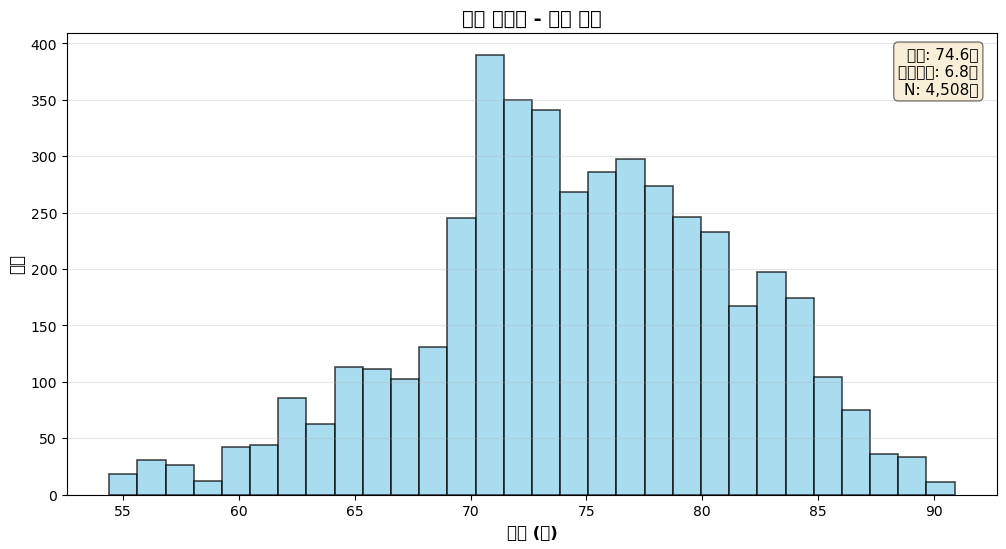

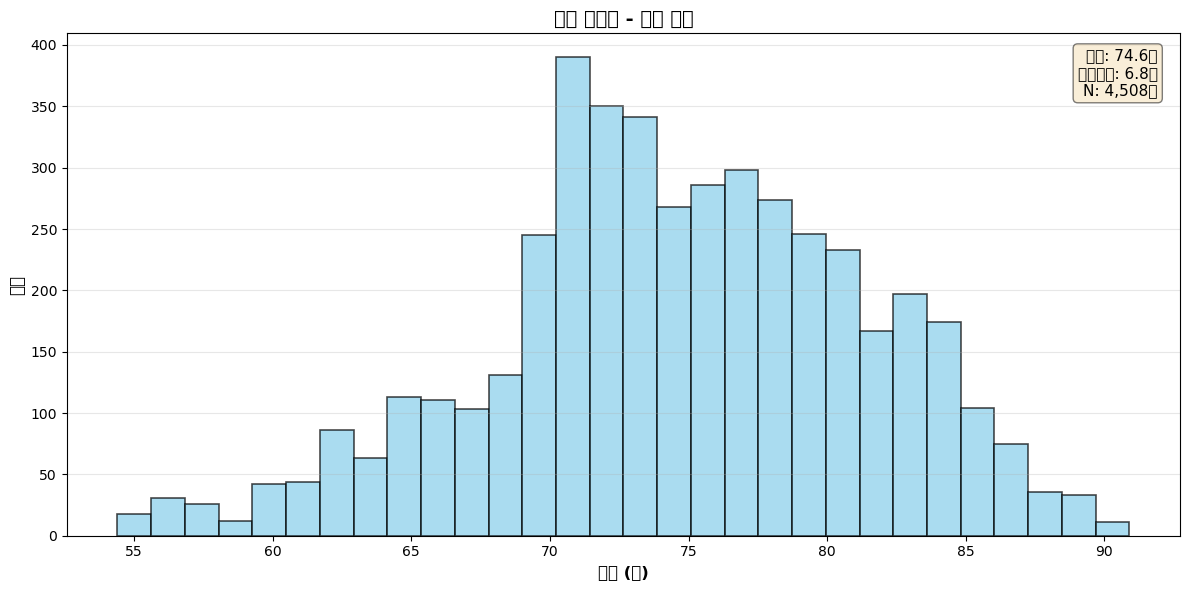


EDA: Variable Distribution Histograms


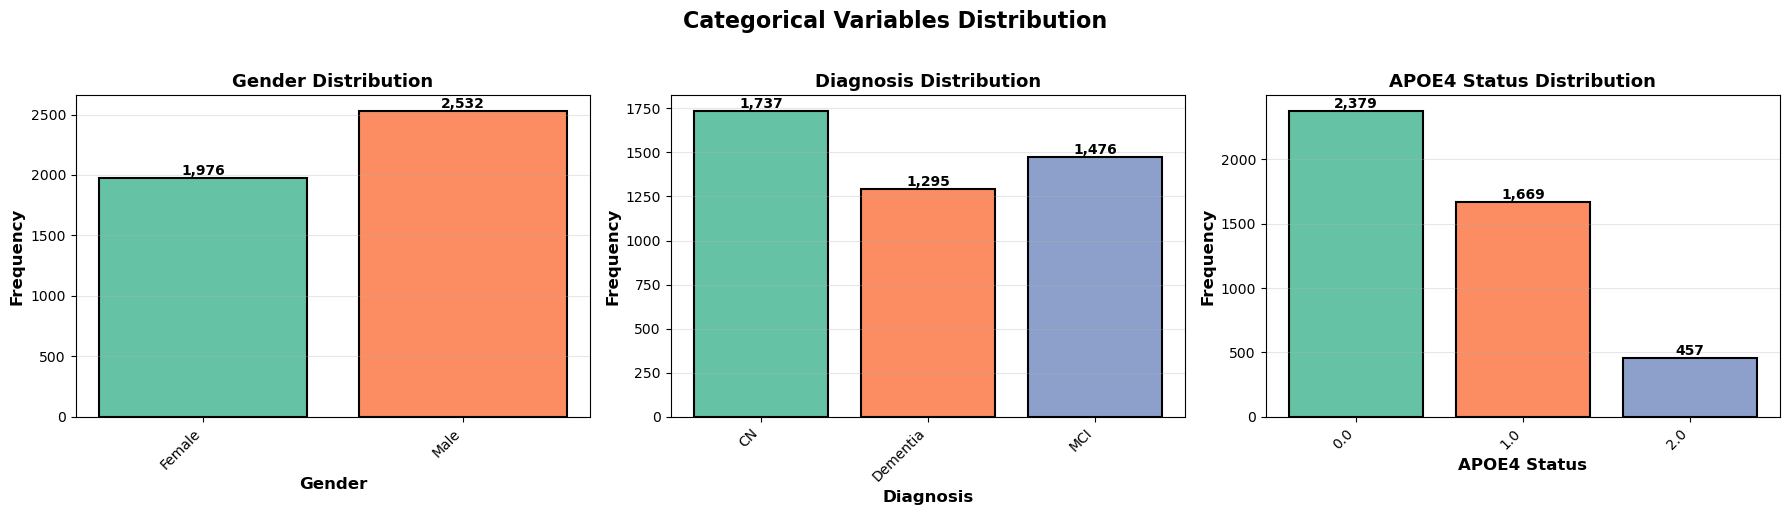

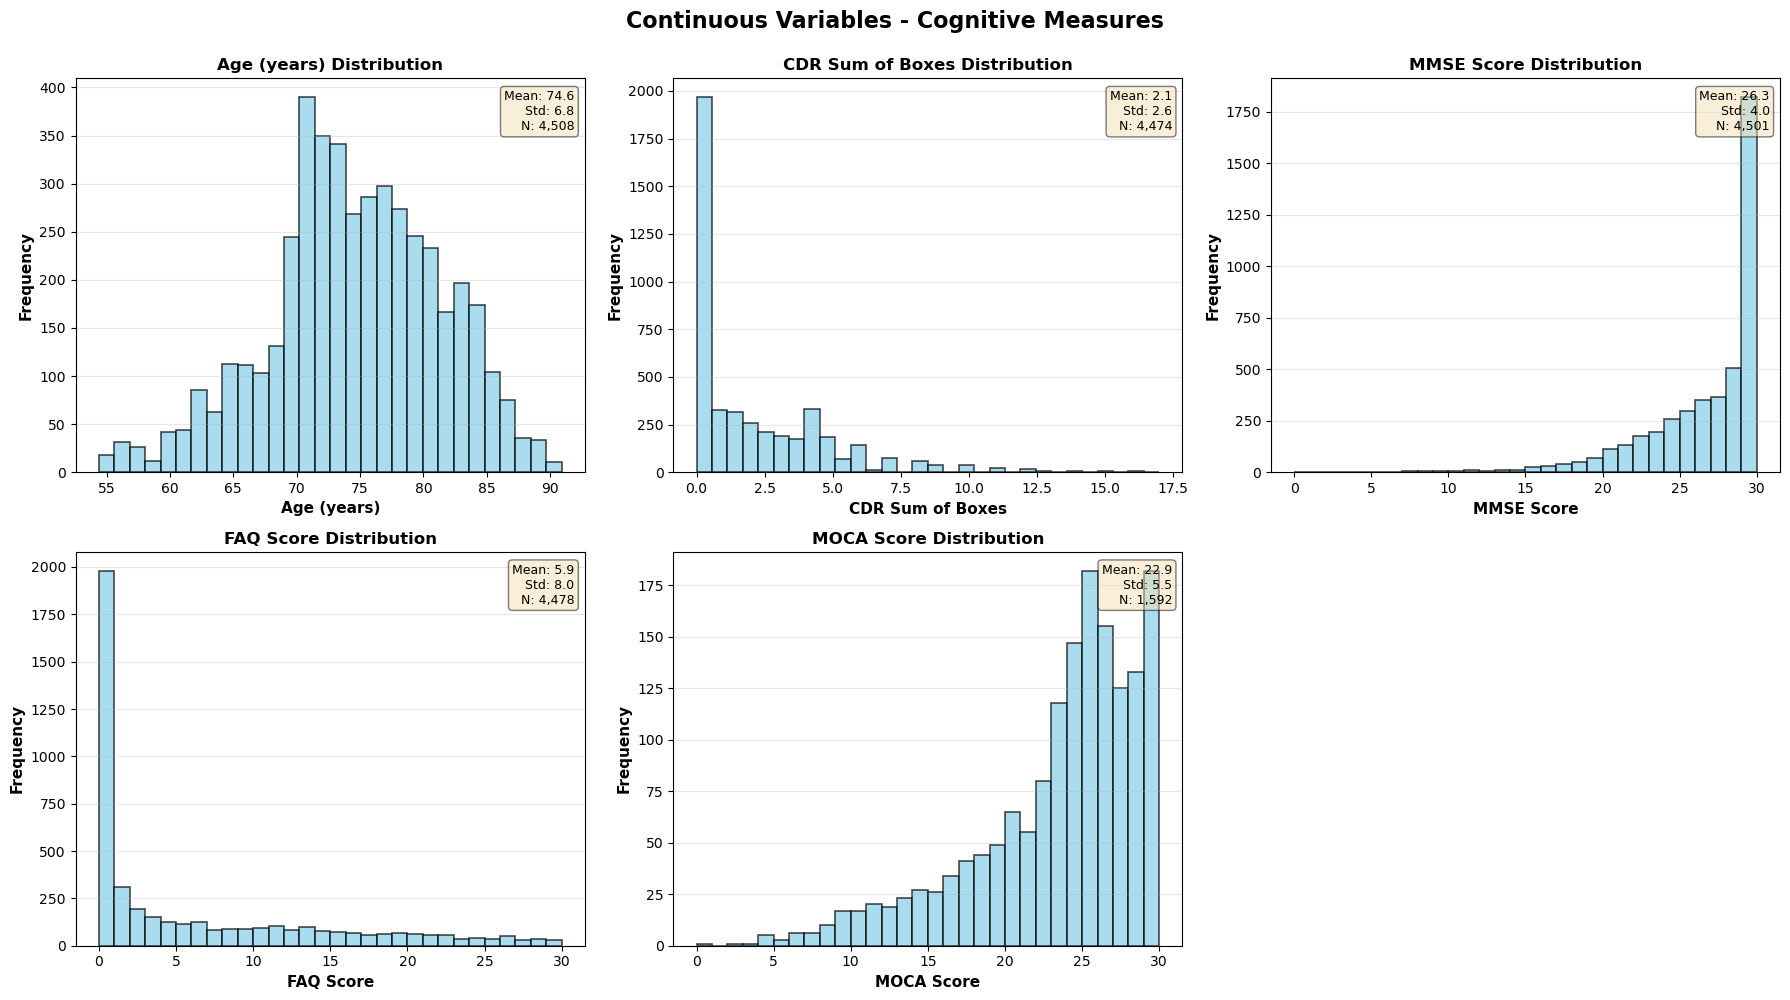

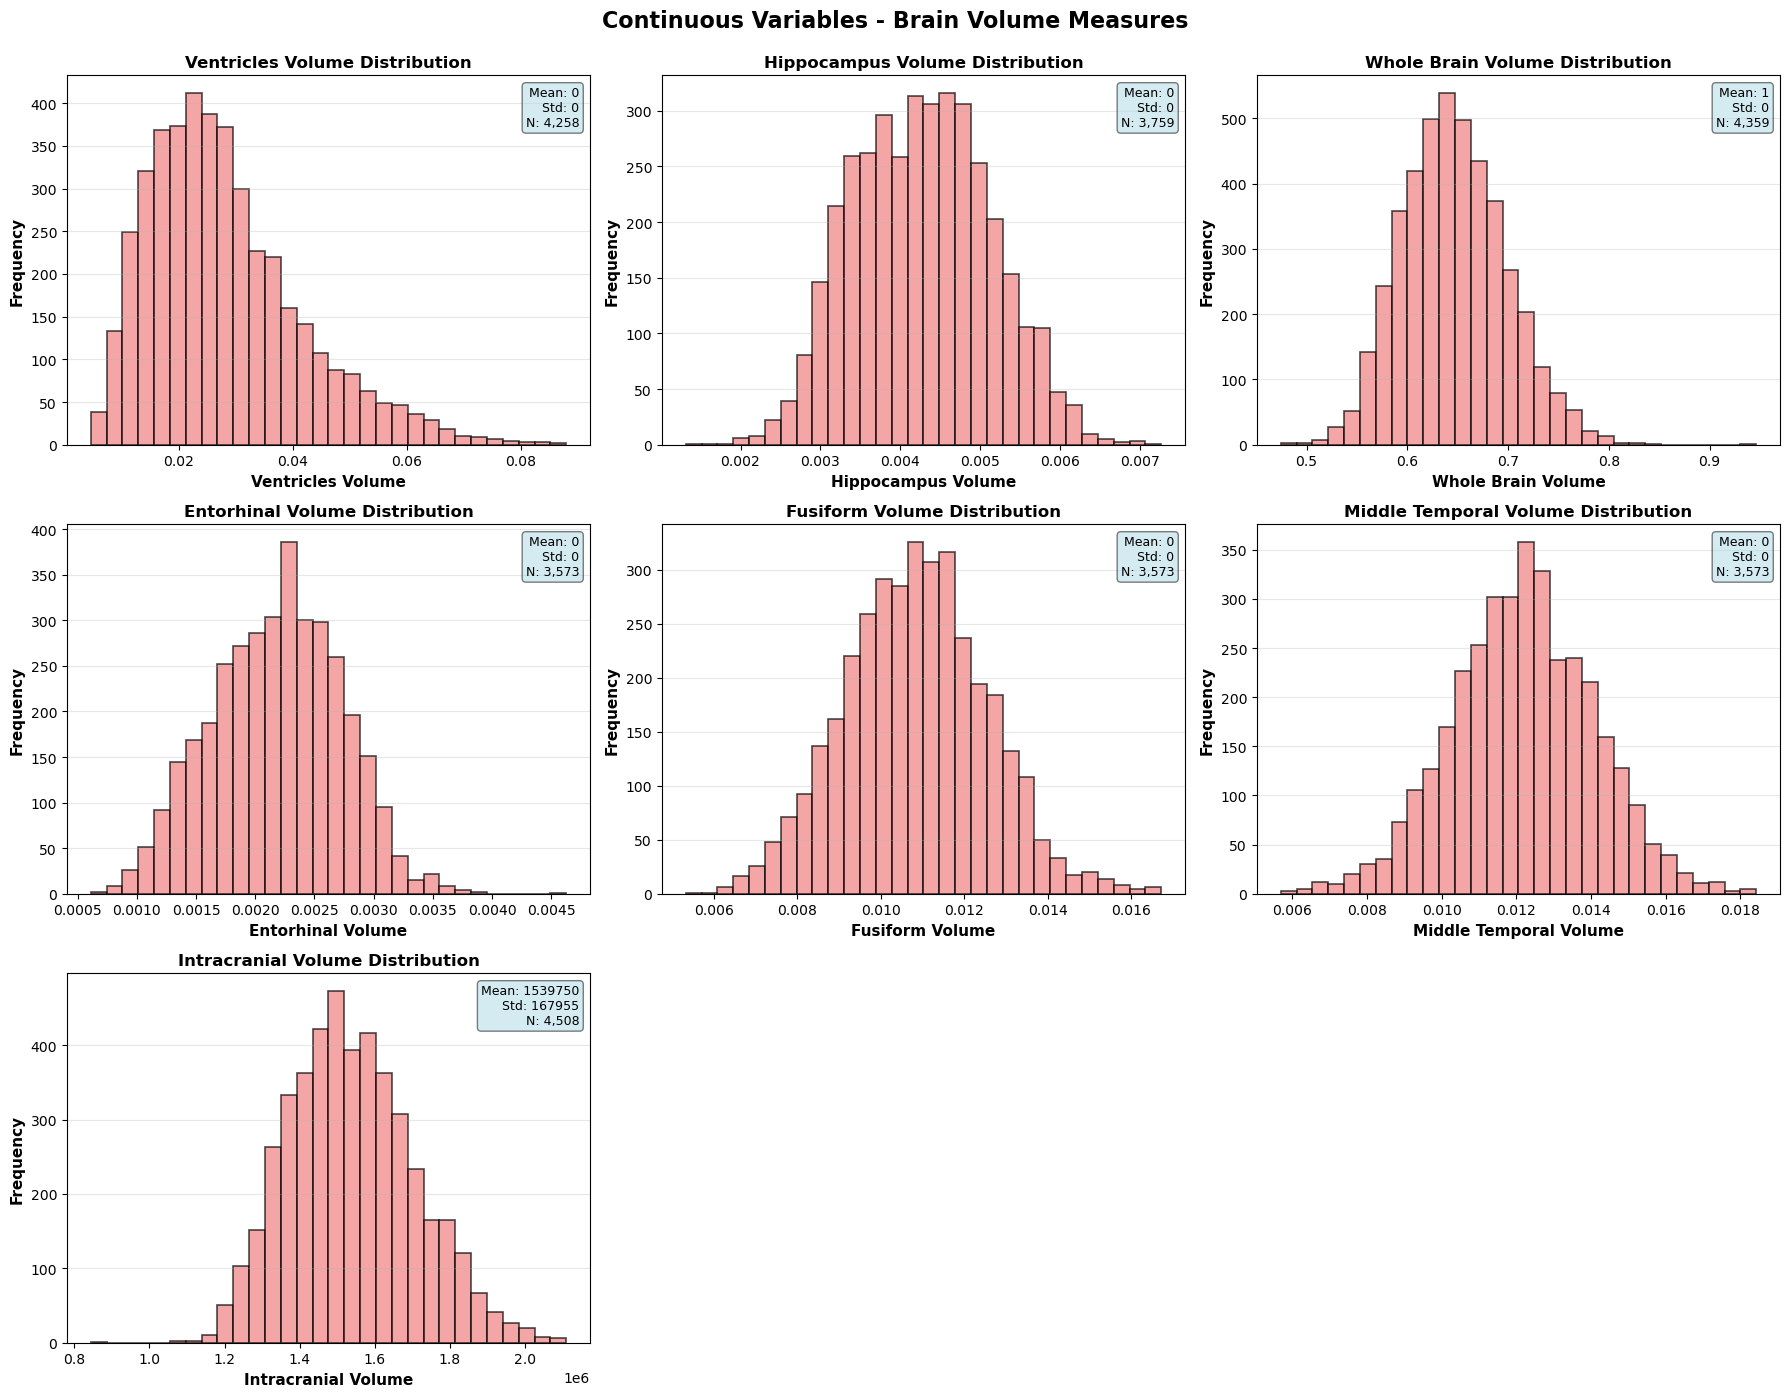

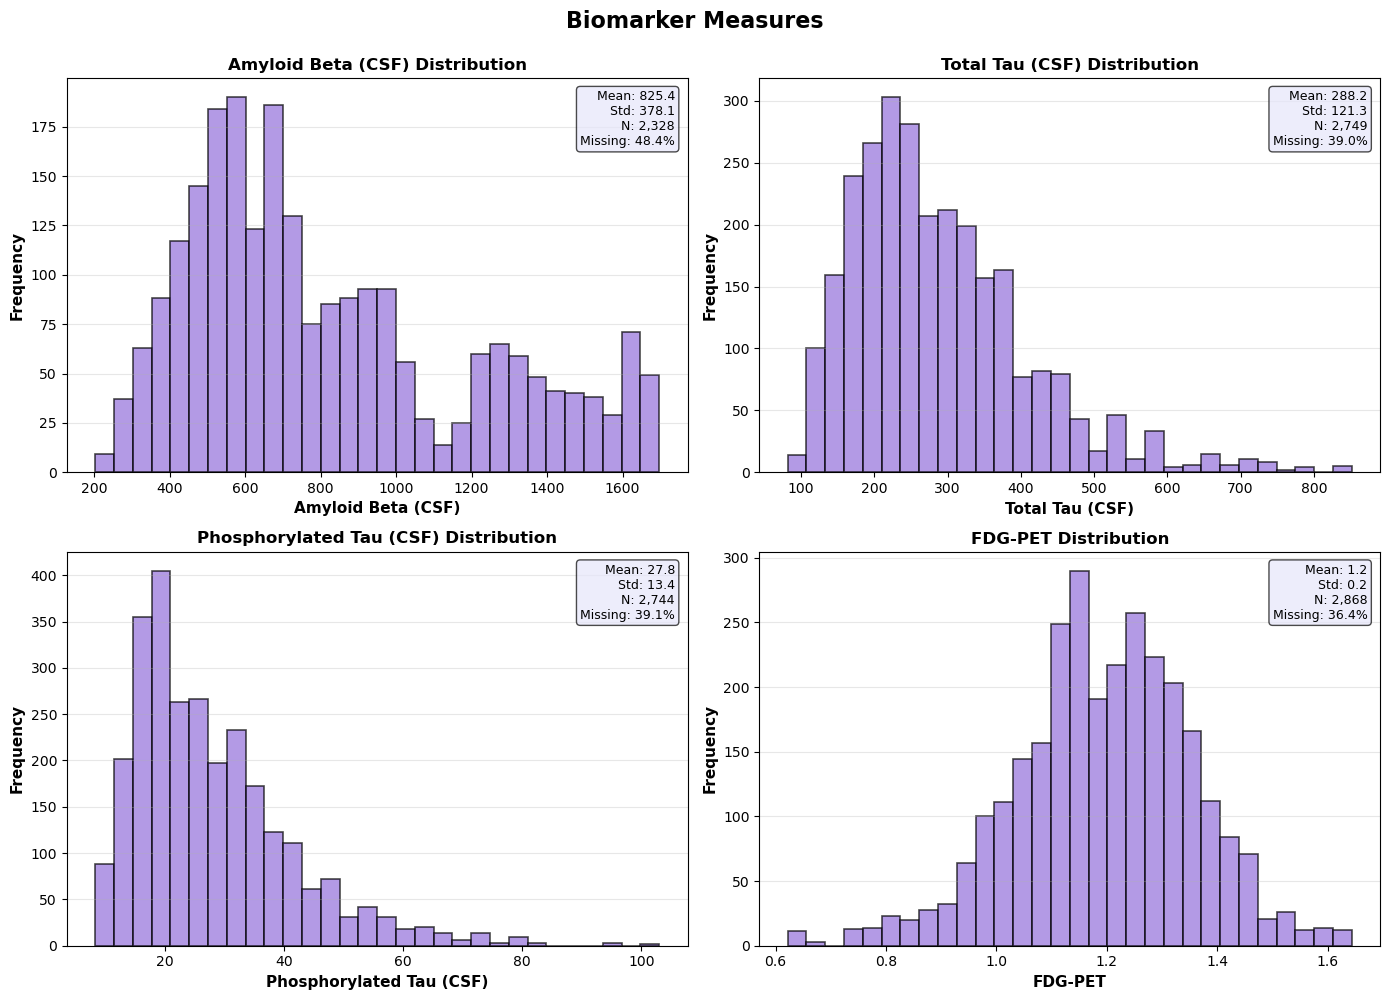


SUMMARY STATISTICS

📊 Categorical Variables:

Gender (PTGENDER):
  Male: 2,532 (56.2%)
  Female: 1,976 (43.8%)

Diagnosis (RS:DX_fill):
  CN: 1,737 (38.5%)
  MCI: 1,476 (32.7%)
  Dementia: 1,295 (28.7%)

APOE4 Status (APOE4):
  0.0: 2,379 (52.8%)
  1.0: 1,669 (37.0%)
  2.0: 457 (10.1%)

📊 Continuous Variables:
               AGE        CDRSB         MMSE          FAQ         MOCA  \
count  4508.000000  4474.000000  4501.000000  4478.000000  1592.000000   
mean     74.597161     2.129861    26.322817     5.882760    22.920854   
std       6.777560     2.649722     4.015137     7.968576     5.506298   
min      54.400000     0.000000     0.000000     0.000000     0.000000   
25%      70.600000     0.000000    24.000000     0.000000    20.000000   
50%      74.300000     1.000000    28.000000     1.000000    24.000000   
75%      79.500000     3.500000    29.000000    11.000000    27.000000   
max      90.900000    17.000000    30.000000    30.000000    30.000000   

        Ventricles  

In [51]:
# 3. 전체 나이 분포
print("="*80)
print("전체 데이터 - 나이 분포")
print("="*80)

# 나이 데이터
age_data = df['AGE'].dropna()

# 통계량 출력
print(f"\n📊 나이 통계:")
print(f"  평균: {age_data.mean():.1f}세")
print(f"  표준편차: {age_data.std():.1f}세")
print(f"  최소값: {age_data.min():.1f}세")
print(f"  최대값: {age_data.max():.1f}세")
print(f"  중앙값: {age_data.median():.1f}세")
print(f"  데이터 개수: {len(age_data):,}명")

# 나이 분포 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(age_data, bins=30, color='skyblue', edgecolor='black', linewidth=1.2, alpha=0.7)

ax.set_xlabel('나이 (세)', fontweight='bold', fontsize=12)
ax.set_ylabel('빈도', fontweight='bold', fontsize=12)
ax.set_title('전체 데이터 - 나이 분포', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# 통계 정보 텍스트 박스
stats_text = f'평균: {age_data.mean():.1f}세\n표준편차: {age_data.std():.1f}세\nN: {len(age_data):,}명'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EDA: Variable Distribution Histograms")
print("="*80)

# Define variables to plot
variables = {
    'Categorical': {
        'PTGENDER': 'Gender',
        'RS:DX_fill': 'Diagnosis',
        'APOE4': 'APOE4 Status'
    },
    'Continuous': {
        'AGE': 'Age (years)',
        'CDRSB': 'CDR Sum of Boxes',
        'MMSE': 'MMSE Score',
        'FAQ': 'FAQ Score',
        'MOCA': 'MOCA Score',
        'Ventricles': 'Ventricles Volume',
        'Hippocampus': 'Hippocampus Volume',
        'WholeBrain': 'Whole Brain Volume',
        'Entorhinal': 'Entorhinal Volume',
        'Fusiform': 'Fusiform Volume',
        'MidTemp': 'Middle Temporal Volume',
        'ICV': 'Intracranial Volume',
        'ABETA_bl': 'Amyloid Beta (CSF)',
        'TAU_bl': 'Total Tau (CSF)',
        'PTAU_bl': 'Phosphorylated Tau (CSF)',
        'FDG_bl': 'FDG-PET'
    }
}

# ============================================================================
# PLOT 1: Categorical Variables
# ============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold', y=1.02)

for idx, (var, label) in enumerate(variables['Categorical'].items()):
    ax = axes1[idx]

    # Count values
    value_counts = df[var].value_counts().sort_index()

    # Create bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values,
                   color=sns.color_palette('Set2', len(value_counts)),
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{label} Distribution', fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Continuous Variables (Part 1 - Cognitive Scores)
# ============================================================================
cognitive_vars = ['AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA']
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

fig2.suptitle('Continuous Variables - Cognitive Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(cognitive_vars):
    ax = axes2[idx]

    # Remove NaN values for plotting
    data = df[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='skyblue', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.1f}\nStd: {data.std():.1f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

# Remove extra subplot
axes2[5].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Continuous Variables (Part 2 - Brain Volumes)
# ============================================================================
brain_vars = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
              'Fusiform', 'MidTemp', 'ICV']
fig3, axes3 = plt.subplots(3, 3, figsize=(18, 14))
axes3 = axes3.flatten()

fig3.suptitle('Continuous Variables - Brain Volume Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(brain_vars):
    ax = axes3[idx]

    # Remove NaN values for plotting
    data = df[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='lightcoral', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.0f}\nStd: {data.std():.0f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
           fontsize=9)

# Remove extra subplots
for i in range(len(brain_vars), 9):
    axes3[i].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 4: Biomarkers (NEW!)
# ============================================================================
biomarker_vars = ['ABETA_bl', 'TAU_bl', 'PTAU_bl', 'FDG_bl']
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
axes4 = axes4.flatten()

fig4.suptitle('Biomarker Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(biomarker_vars):
    ax = axes4[idx]

    # Convert to numeric and remove NaN values
    data = pd.to_numeric(df[var], errors='coerce').dropna()

    # Create histogram
    ax.hist(data, bins=30, color='mediumpurple', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text with missing data info
    missing_pct = 100 * (1 - len(data) / len(df))
    stats_text = f'Mean: {data.mean():.1f}\nStd: {data.std():.1f}\nN: {len(data):,}'
    if missing_pct > 0:
        stats_text += f'\nMissing: {missing_pct:.1f}%'

    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.7),
           fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 Categorical Variables:")
for var, label in variables['Categorical'].items():
    print(f"\n{label} ({var}):")
    value_counts = df[var].value_counts()
    for val, count in value_counts.items():
        pct = 100 * count / len(df)
        print(f"  {val}: {count:,} ({pct:.1f}%)")

print("\n📊 Continuous Variables:")
continuous_all = list(variables['Continuous'].keys())
# Convert biomarkers to numeric
df_stats = df.copy()
for var in biomarker_vars:
    df_stats[var] = pd.to_numeric(df_stats[var], errors='coerce')
stats_df = df_stats[continuous_all].describe()
print(stats_df)

CN (Cognitively Normal) - 나이 분포

📊 나이 통계:
  평균: 74.5세
  표준편차: 5.8세
  최소값: 56.2세
  최대값: 89.6세
  중앙값: 73.7세
  데이터 개수: 1,737명


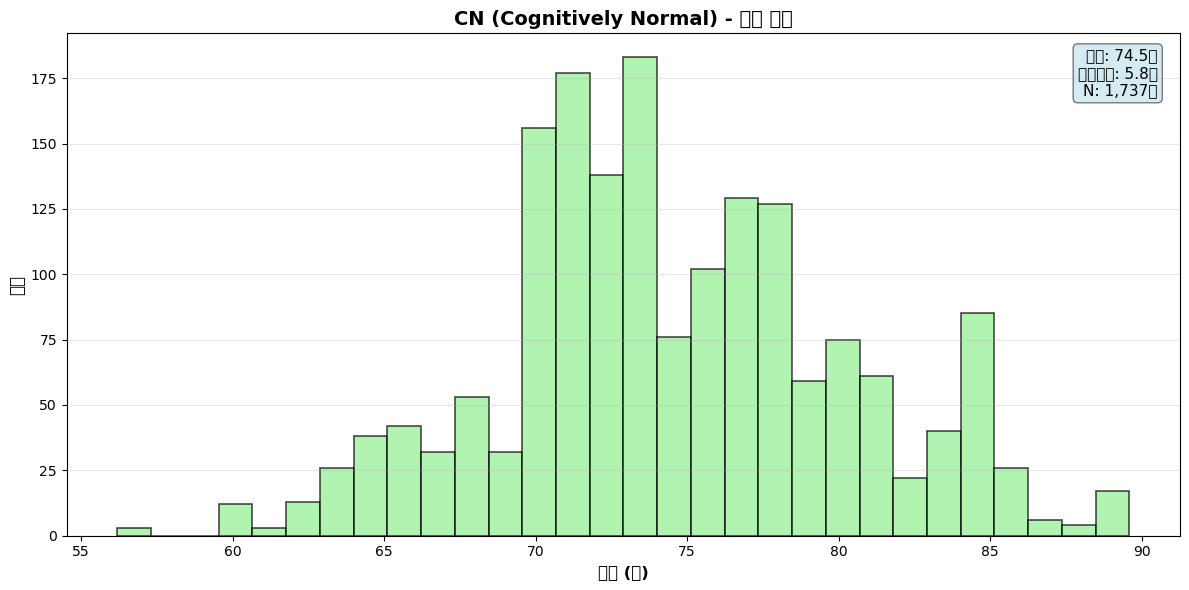


EXPLORATORY DATA ANALYSIS - CN


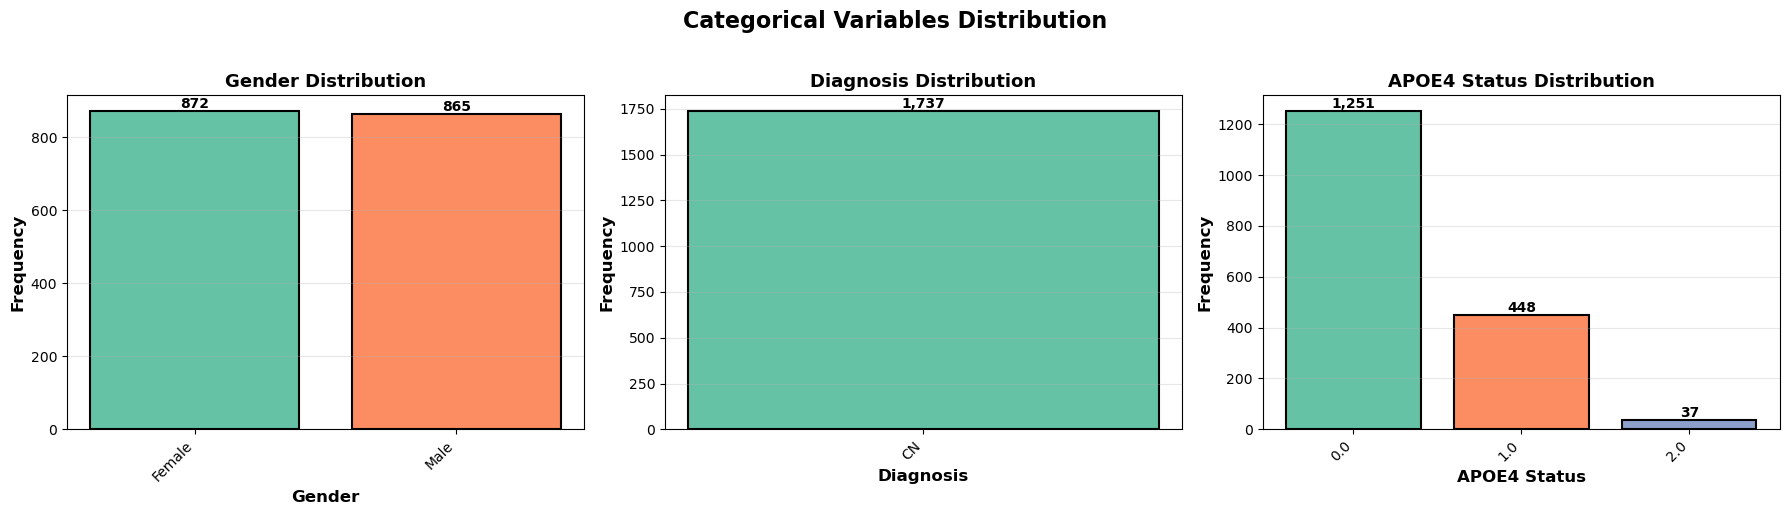

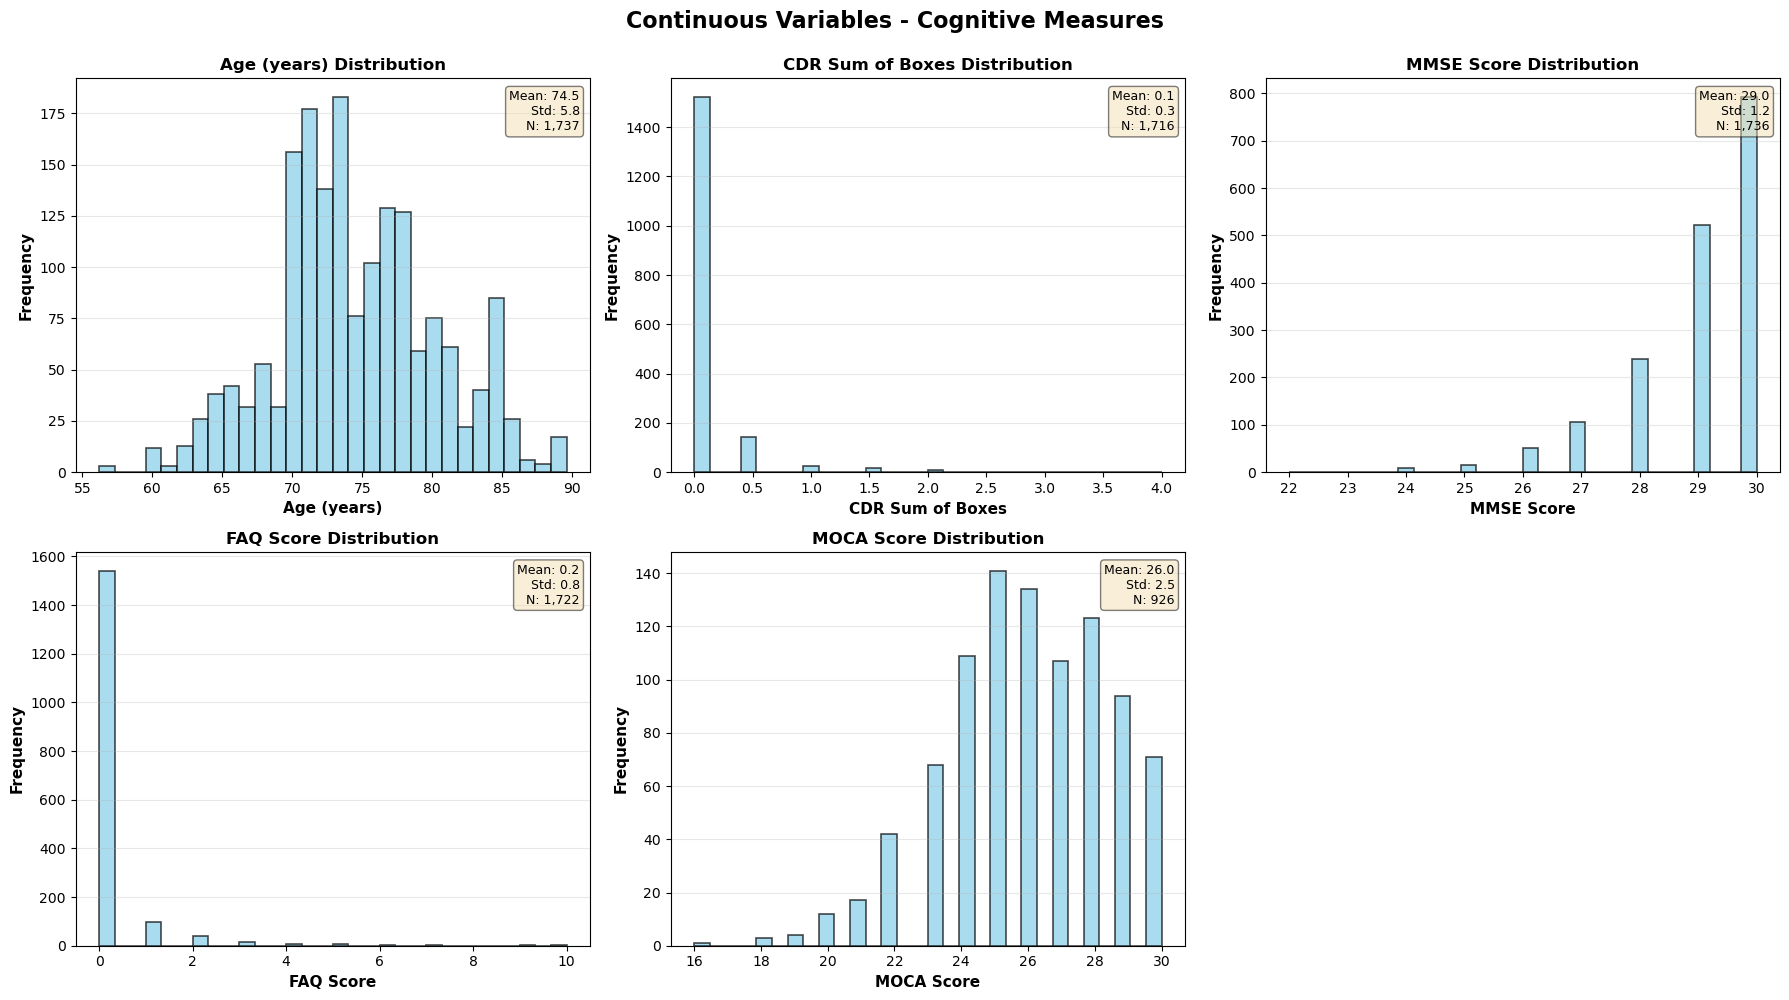

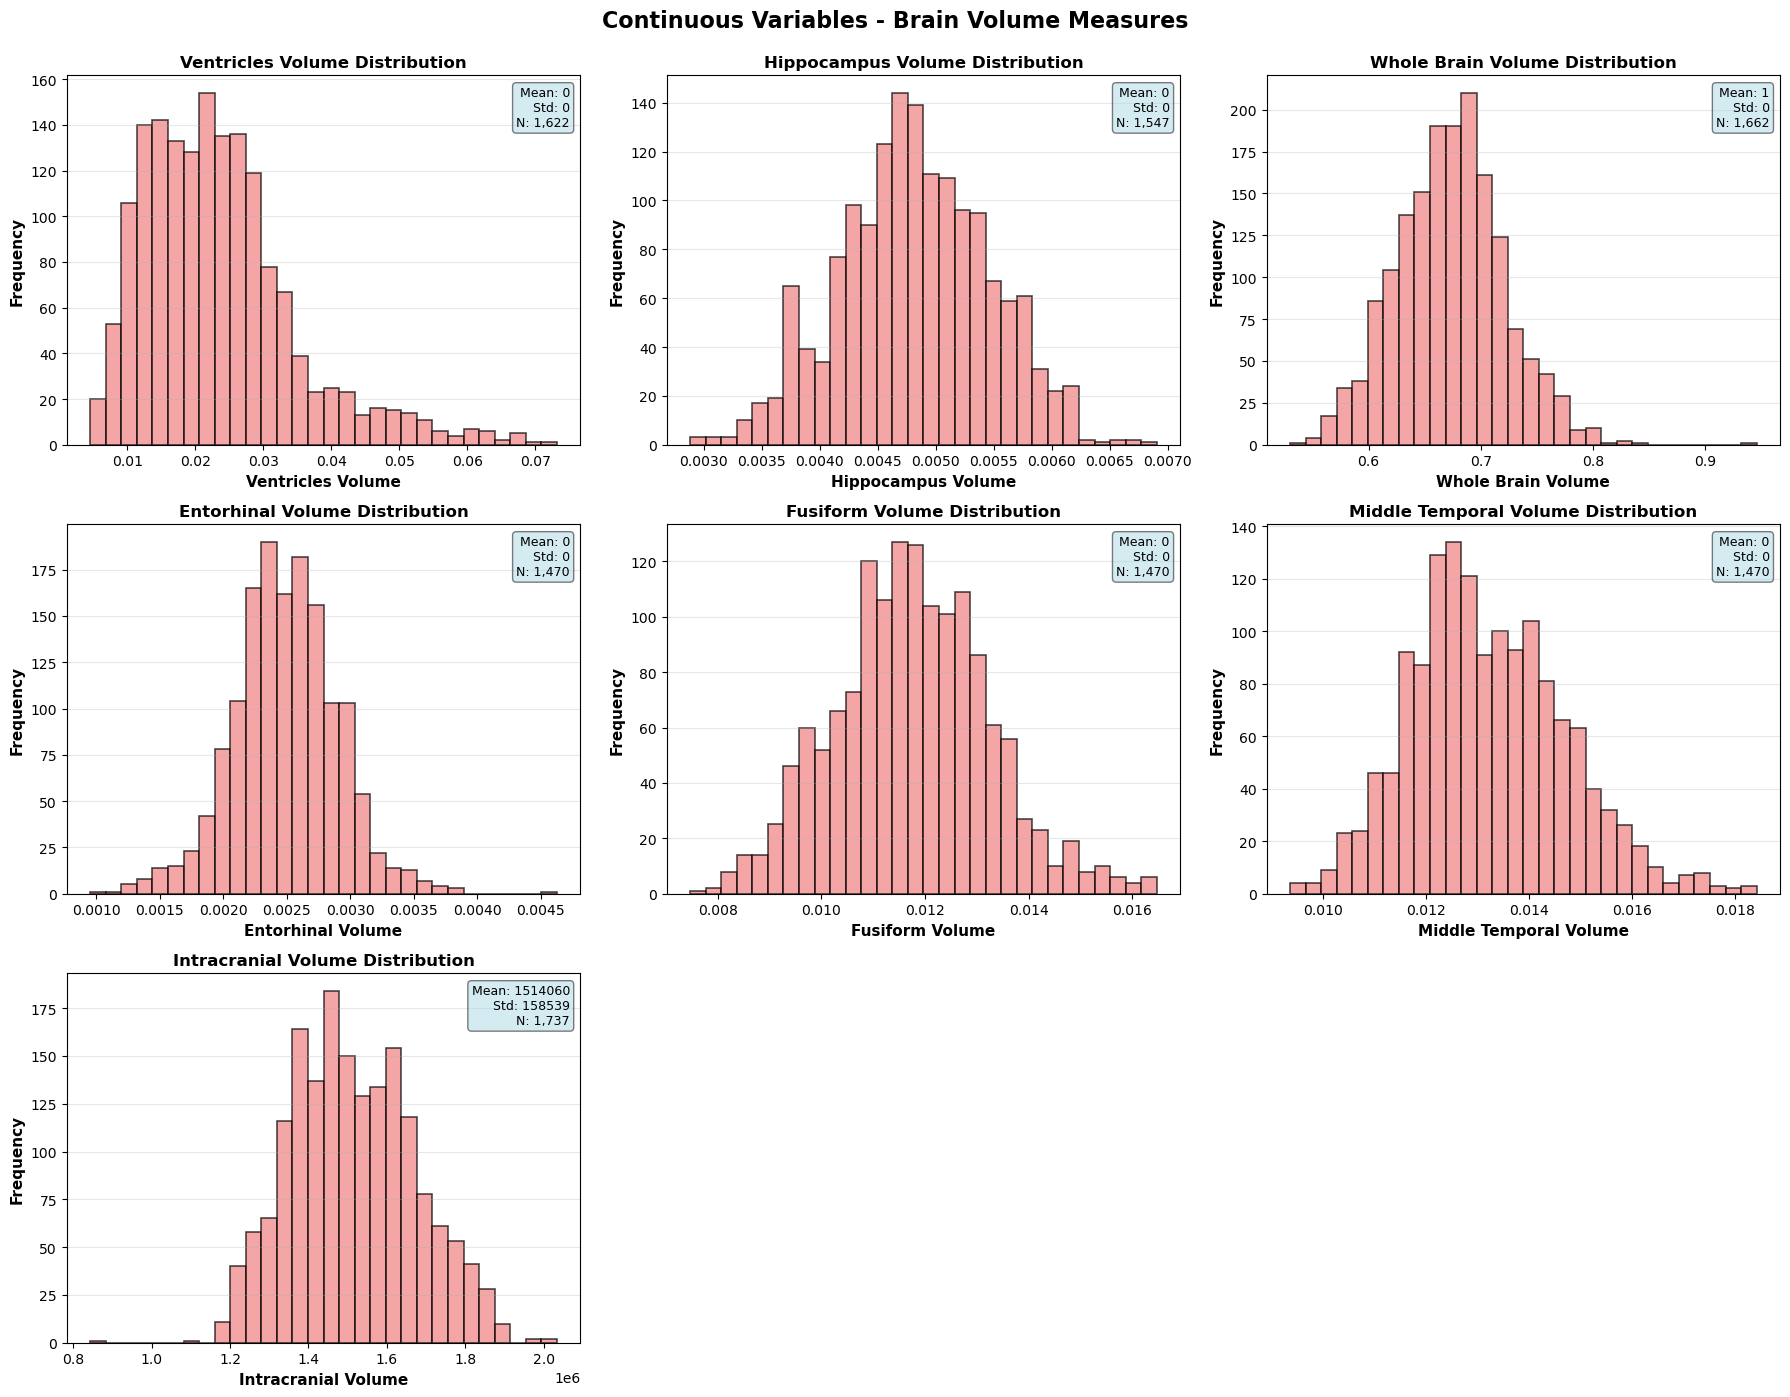


SUMMARY STATISTICS

📊 Categorical Variables:

Gender (PTGENDER):
  Female: 872 (50.2%)
  Male: 865 (49.8%)

Diagnosis (RS:DX_fill):
  CN: 1,737 (100.0%)

APOE4 Status (APOE4):
  0.0: 1,251 (72.0%)
  1.0: 448 (25.8%)
  2.0: 37 (2.1%)

📊 Continuous Variables:
               AGE        CDRSB         MMSE          FAQ        MOCA  \
count  1737.000000  1716.000000  1736.000000  1722.000000  926.000000   
mean     74.523777     0.084499    29.040323     0.204994   25.966523   
std       5.756577     0.293514     1.187150     0.776109    2.501019   
min      56.200000     0.000000    22.000000     0.000000   16.000000   
25%      70.800000     0.000000    29.000000     0.000000   24.000000   
50%      73.700000     0.000000    29.000000     0.000000   26.000000   
75%      78.200000     0.000000    30.000000     0.000000   28.000000   
max      89.600000     4.000000    30.000000    10.000000   30.000000   

        Ventricles  Hippocampus   WholeBrain   Entorhinal     Fusiform  \
count  16

In [52]:
# 4. CN 나이 분포
df_cn = df[df['RS:DX_fill'] == 'CN']

print("="*80)
print("CN (Cognitively Normal) - 나이 분포")
print("="*80)

# 나이 데이터
age_data = df_cn['AGE'].dropna()

# 통계량 출력
print(f"\n📊 나이 통계:")
print(f"  평균: {age_data.mean():.1f}세")
print(f"  표준편차: {age_data.std():.1f}세")
print(f"  최소값: {age_data.min():.1f}세")
print(f"  최대값: {age_data.max():.1f}세")
print(f"  중앙값: {age_data.median():.1f}세")
print(f"  데이터 개수: {len(age_data):,}명")

# 나이 분포 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(age_data, bins=30, color='lightgreen', edgecolor='black', linewidth=1.2, alpha=0.7)

ax.set_xlabel('나이 (세)', fontweight='bold', fontsize=12)
ax.set_ylabel('빈도', fontweight='bold', fontsize=12)
ax.set_title('CN (Cognitively Normal) - 나이 분포', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# 통계 정보 텍스트 박스
stats_text = f'평균: {age_data.mean():.1f}세\n표준편차: {age_data.std():.1f}세\nN: {len(age_data):,}명'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS - CN")
print("="*80)

# Define variables to plot
variables = {
    'Categorical': {
        'PTGENDER': 'Gender',
        'RS:DX_fill': 'Diagnosis',
        'APOE4': 'APOE4 Status'
    },
    'Continuous': {
        'AGE': 'Age (years)',
        'CDRSB': 'CDR Sum of Boxes',
        'MMSE': 'MMSE Score',
        'FAQ': 'FAQ Score',
        'MOCA': 'MOCA Score',
        'Ventricles': 'Ventricles Volume',
        'Hippocampus': 'Hippocampus Volume',
        'WholeBrain': 'Whole Brain Volume',
        'Entorhinal': 'Entorhinal Volume',
        'Fusiform': 'Fusiform Volume',
        'MidTemp': 'Middle Temporal Volume',
        'ICV': 'Intracranial Volume'
    }
}

# ============================================================================
# PLOT 1: Categorical Variables
# ============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold', y=1.02)

for idx, (var, label) in enumerate(variables['Categorical'].items()):
    ax = axes1[idx]

    # Count values
    value_counts = df_cn[var].value_counts().sort_index()

    # Create bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values,
                   color=sns.color_palette('Set2', len(value_counts)),
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{label} Distribution', fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Continuous Variables (Part 1 - Cognitive Scores)
# ============================================================================
cognitive_vars = ['AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA']
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

fig2.suptitle('Continuous Variables - Cognitive Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(cognitive_vars):
    ax = axes2[idx]

    # Remove NaN values for plotting
    data = df_cn[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='skyblue', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.1f}\nStd: {data.std():.1f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

# Remove extra subplot
axes2[5].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Continuous Variables (Part 2 - Brain Volumes)
# ============================================================================
brain_vars = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
              'Fusiform', 'MidTemp', 'ICV']
fig3, axes3 = plt.subplots(3, 3, figsize=(18, 14))
axes3 = axes3.flatten()

fig3.suptitle('Continuous Variables - Brain Volume Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(brain_vars):
    ax = axes3[idx]

    # Remove NaN values for plotting
    data = df_cn[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='lightcoral', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.0f}\nStd: {data.std():.0f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
           fontsize=9)

# Remove extra subplots
for i in range(len(brain_vars), 9):
    axes3[i].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 Categorical Variables:")
for var, label in variables['Categorical'].items():
    print(f"\n{label} ({var}):")
    value_counts = df_cn[var].value_counts()
    for val, count in value_counts.items():
        pct = 100 * count / len(df_cn)
        print(f"  {val}: {count:,} ({pct:.1f}%)")

print("\n📊 Continuous Variables:")
continuous_all = list(variables['Continuous'].keys())
stats_df = df_cn[continuous_all].describe()
print(stats_df)

MCI (Mild Cognitive Impairment) - 나이 분포

📊 나이 통계:
  평균: 74.5세
  표준편차: 7.3세
  최소값: 54.4세
  최대값: 89.3세
  중앙값: 74.4세
  데이터 개수: 1,476명


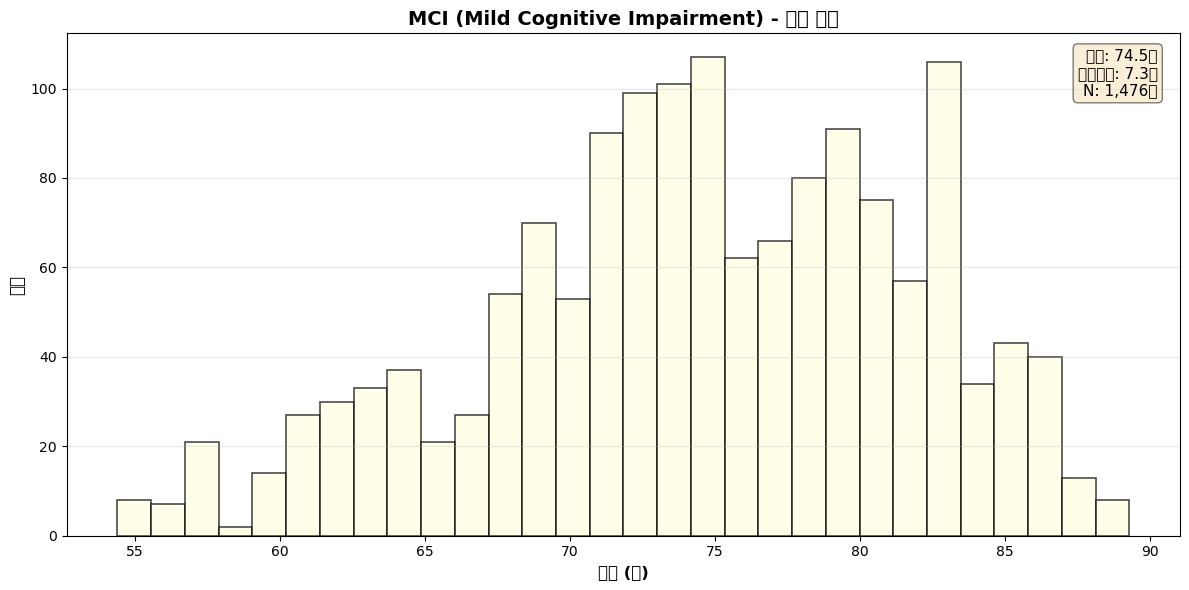


EXPLORATORY DATA ANALYSIS - MCI


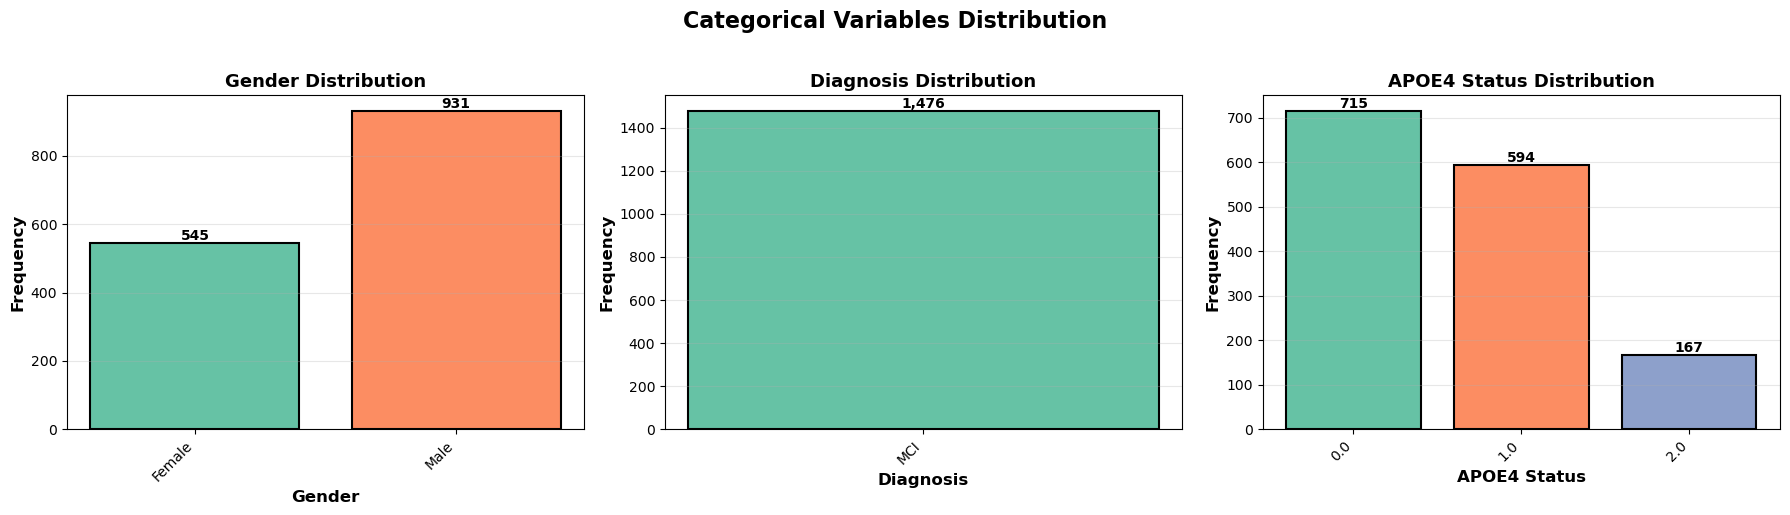

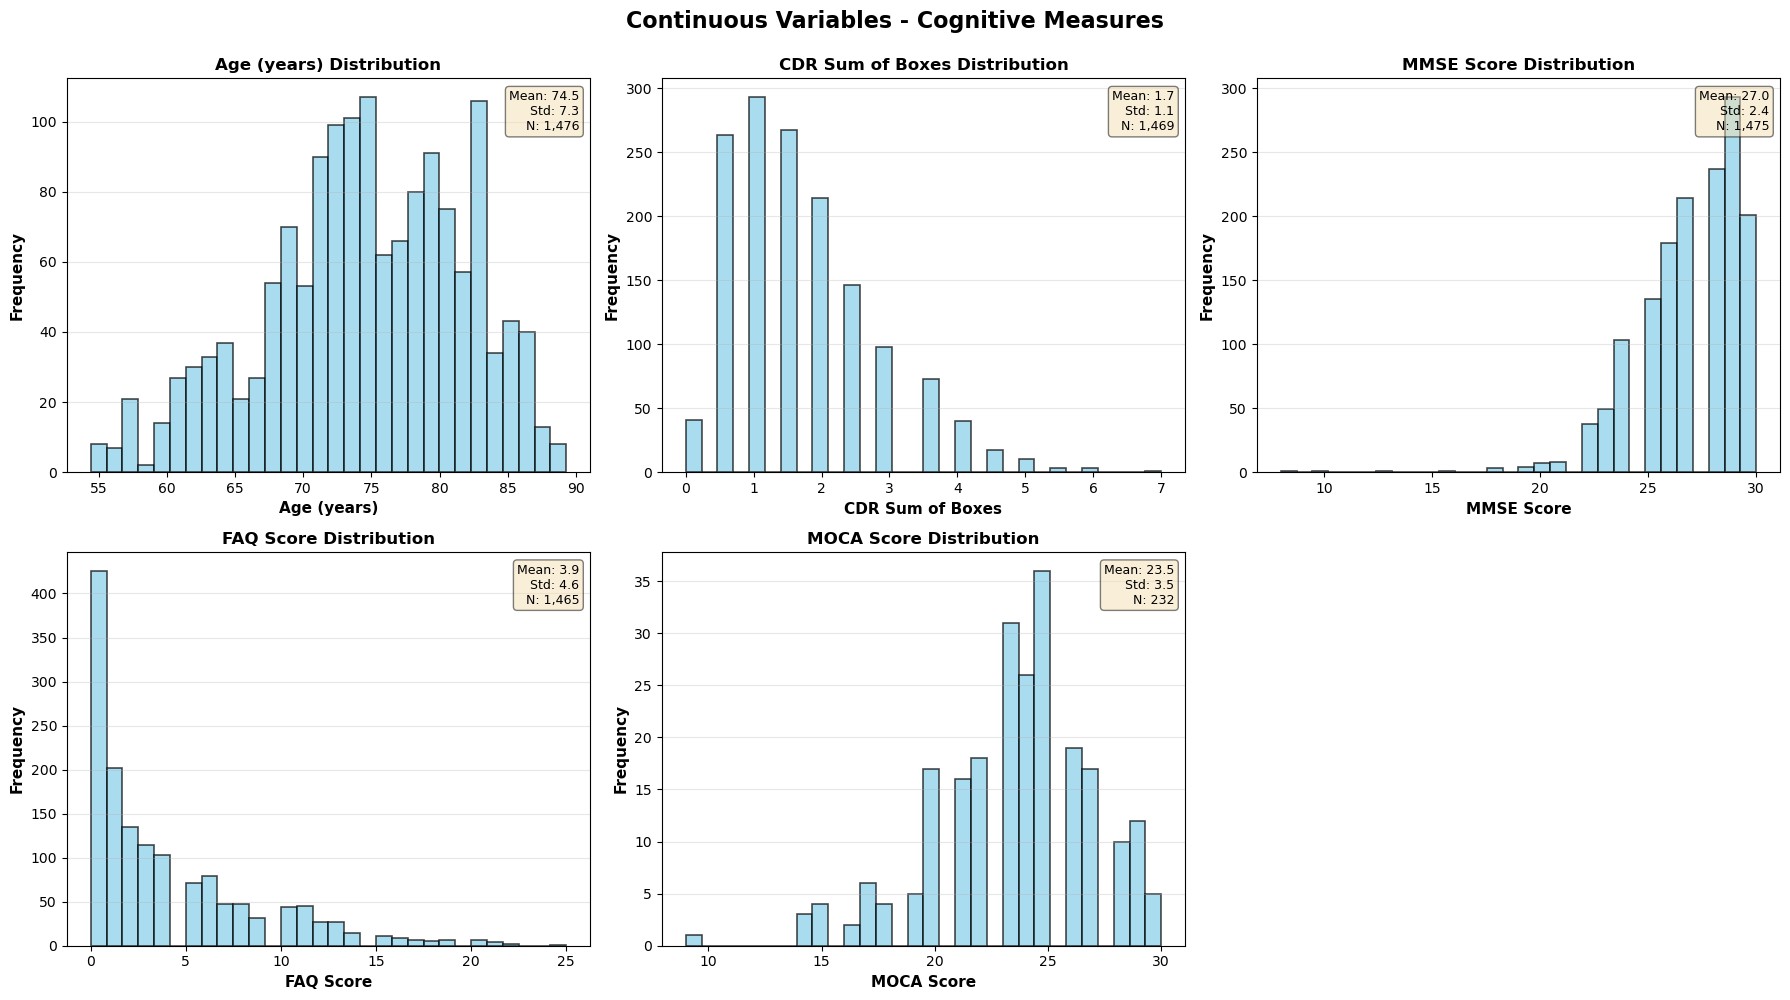

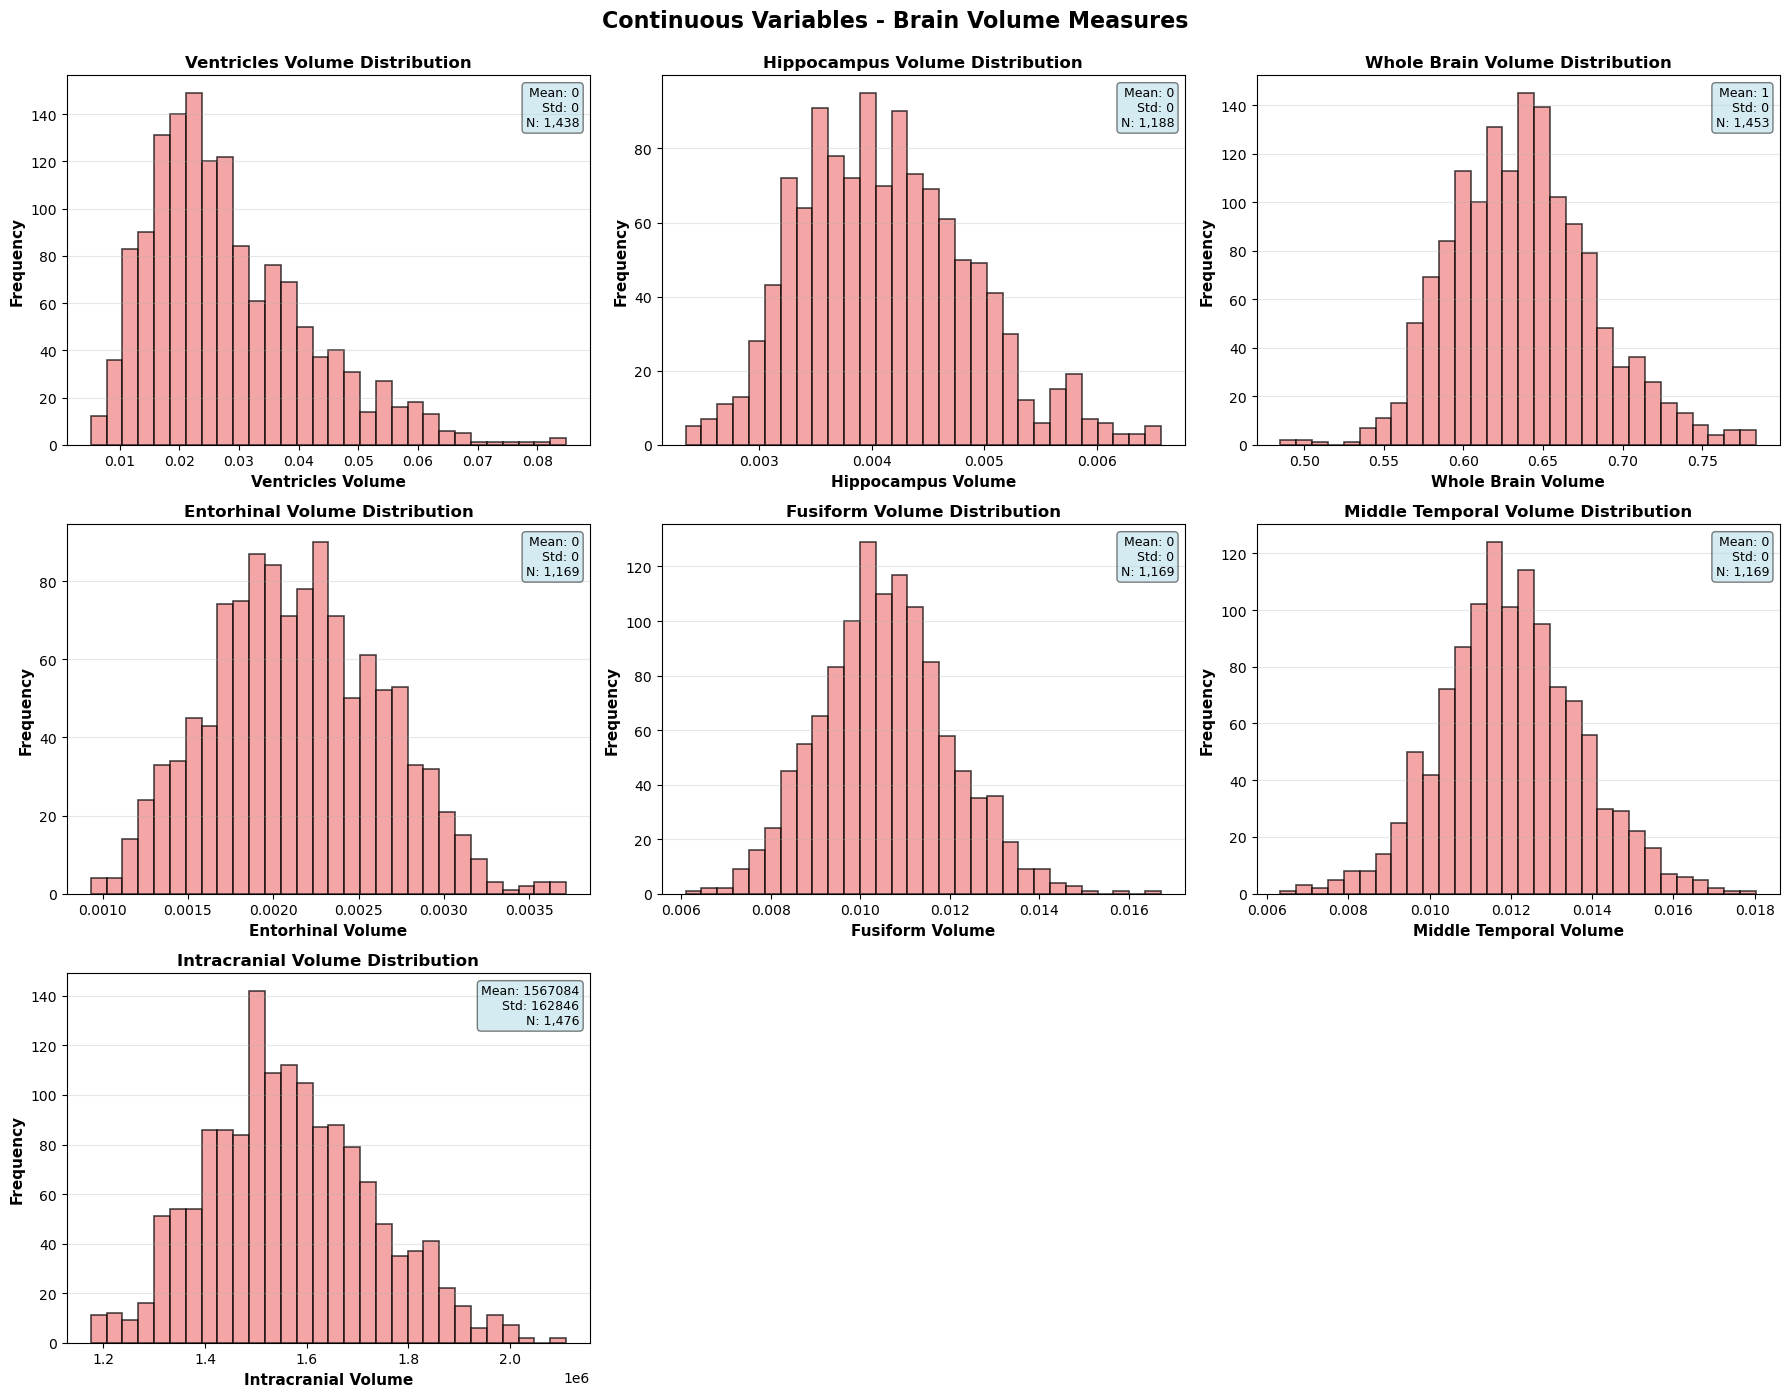


SUMMARY STATISTICS

📊 Categorical Variables:

Gender (PTGENDER):
  Male: 931 (63.1%)
  Female: 545 (36.9%)

Diagnosis (RS:DX_fill):
  MCI: 1,476 (100.0%)

APOE4 Status (APOE4):
  0.0: 715 (48.4%)
  1.0: 594 (40.2%)
  2.0: 167 (11.3%)

📊 Continuous Variables:
               AGE        CDRSB         MMSE          FAQ        MOCA  \
count  1476.000000  1469.000000  1475.000000  1465.000000  232.000000   
mean     74.487466     1.698775    27.044068     3.940614   23.500000   
std       7.254523     1.090883     2.428368     4.584501    3.546842   
min      54.400000     0.000000     8.000000     0.000000    9.000000   
25%      70.300000     1.000000    26.000000     0.000000   21.750000   
50%      74.400000     1.500000    27.000000     2.000000   24.000000   
75%      80.200000     2.500000    29.000000     6.000000   26.000000   
max      89.300000     7.000000    30.000000    25.000000   30.000000   

        Ventricles  Hippocampus   WholeBrain   Entorhinal     Fusiform  \
count  1

In [53]:
# 5. MCI 나이 분포
df_mci = df[df['RS:DX_fill'] == 'MCI']

print("="*80)
print("MCI (Mild Cognitive Impairment) - 나이 분포")
print("="*80)

# 나이 데이터
age_data = df_mci['AGE'].dropna()

# 통계량 출력
print(f"\n📊 나이 통계:")
print(f"  평균: {age_data.mean():.1f}세")
print(f"  표준편차: {age_data.std():.1f}세")
print(f"  최소값: {age_data.min():.1f}세")
print(f"  최대값: {age_data.max():.1f}세")
print(f"  중앙값: {age_data.median():.1f}세")
print(f"  데이터 개수: {len(age_data):,}명")

# 나이 분포 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(age_data, bins=30, color='lightyellow', edgecolor='black', linewidth=1.2, alpha=0.7)

ax.set_xlabel('나이 (세)', fontweight='bold', fontsize=12)
ax.set_ylabel('빈도', fontweight='bold', fontsize=12)
ax.set_title('MCI (Mild Cognitive Impairment) - 나이 분포', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# 통계 정보 텍스트 박스
stats_text = f'평균: {age_data.mean():.1f}세\n표준편차: {age_data.std():.1f}세\nN: {len(age_data):,}명'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS - MCI")
print("="*80)

# Define variables to plot
variables = {
    'Categorical': {
        'PTGENDER': 'Gender',
        'RS:DX_fill': 'Diagnosis',
        'APOE4': 'APOE4 Status'
    },
    'Continuous': {
        'AGE': 'Age (years)',
        'CDRSB': 'CDR Sum of Boxes',
        'MMSE': 'MMSE Score',
        'FAQ': 'FAQ Score',
        'MOCA': 'MOCA Score',
        'Ventricles': 'Ventricles Volume',
        'Hippocampus': 'Hippocampus Volume',
        'WholeBrain': 'Whole Brain Volume',
        'Entorhinal': 'Entorhinal Volume',
        'Fusiform': 'Fusiform Volume',
        'MidTemp': 'Middle Temporal Volume',
        'ICV': 'Intracranial Volume'
    }
}

# ============================================================================
# PLOT 1: Categorical Variables
# ============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold', y=1.02)

for idx, (var, label) in enumerate(variables['Categorical'].items()):
    ax = axes1[idx]

    # Count values
    value_counts = df_mci[var].value_counts().sort_index()

    # Create bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values,
                   color=sns.color_palette('Set2', len(value_counts)),
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{label} Distribution', fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Continuous Variables (Part 1 - Cognitive Scores)
# ============================================================================
cognitive_vars = ['AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA']
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

fig2.suptitle('Continuous Variables - Cognitive Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(cognitive_vars):
    ax = axes2[idx]

    # Remove NaN values for plotting
    data = df_mci[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='skyblue', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.1f}\nStd: {data.std():.1f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

# Remove extra subplot
axes2[5].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Continuous Variables (Part 2 - Brain Volumes)
# ============================================================================
brain_vars = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
              'Fusiform', 'MidTemp', 'ICV']
fig3, axes3 = plt.subplots(3, 3, figsize=(18, 14))
axes3 = axes3.flatten()

fig3.suptitle('Continuous Variables - Brain Volume Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(brain_vars):
    ax = axes3[idx]

    # Remove NaN values for plotting
    data = df_mci[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='lightcoral', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.0f}\nStd: {data.std():.0f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
           fontsize=9)

# Remove extra subplots
for i in range(len(brain_vars), 9):
    axes3[i].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 Categorical Variables:")
for var, label in variables['Categorical'].items():
    print(f"\n{label} ({var}):")
    value_counts = df_mci[var].value_counts()
    for val, count in value_counts.items():
        pct = 100 * count / len(df_mci)
        print(f"  {val}: {count:,} ({pct:.1f}%)")

print("\n📊 Continuous Variables:")
continuous_all = list(variables['Continuous'].keys())
stats_df = df_mci[continuous_all].describe()
print(stats_df)

Dementia - 나이 분포

📊 나이 통계:
  평균: 74.8세
  표준편차: 7.4세
  최소값: 55.1세
  최대값: 90.9세
  중앙값: 75.4세
  데이터 개수: 1,295명


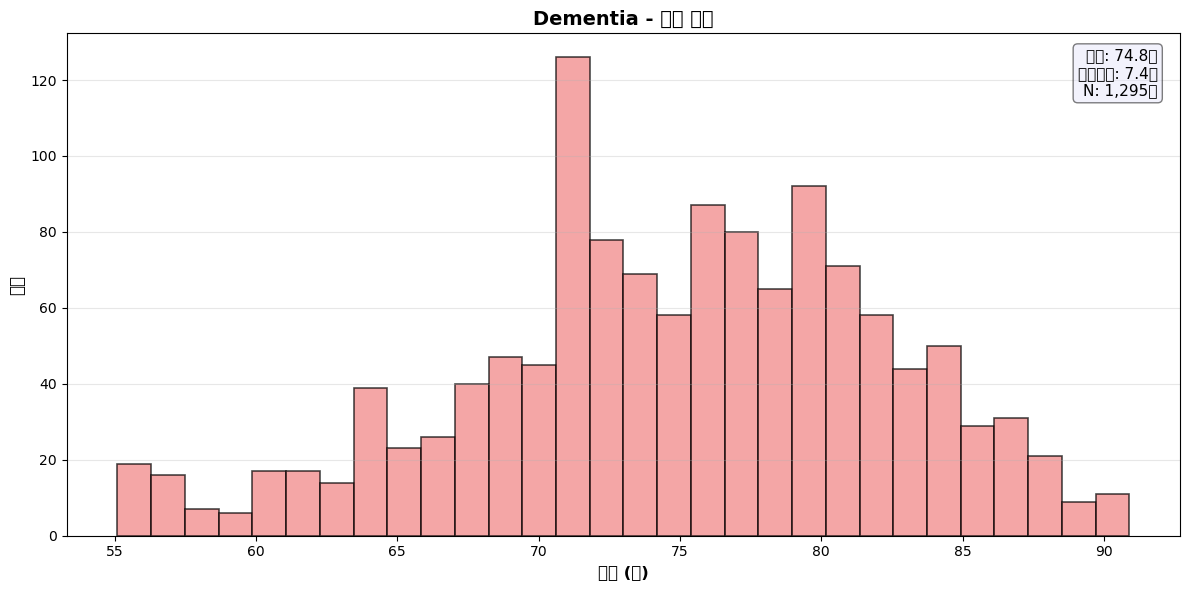


EXPLORATORY DATA ANALYSIS - Dementia


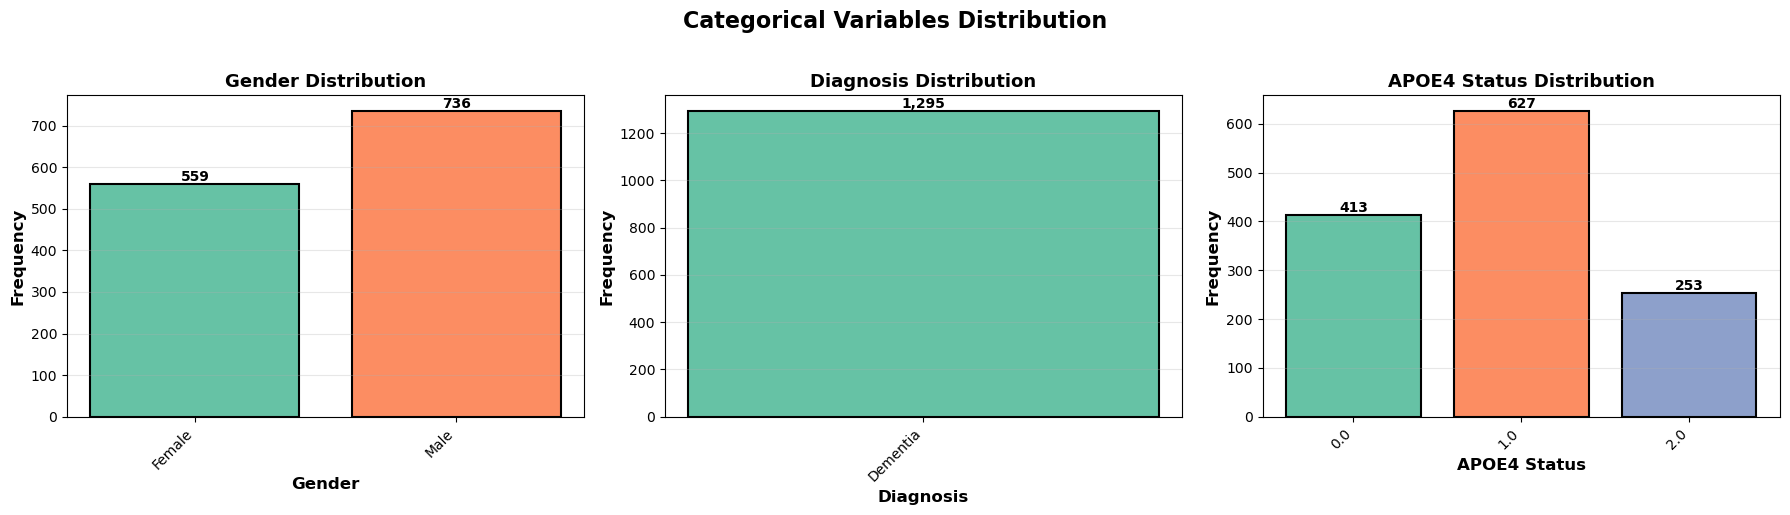

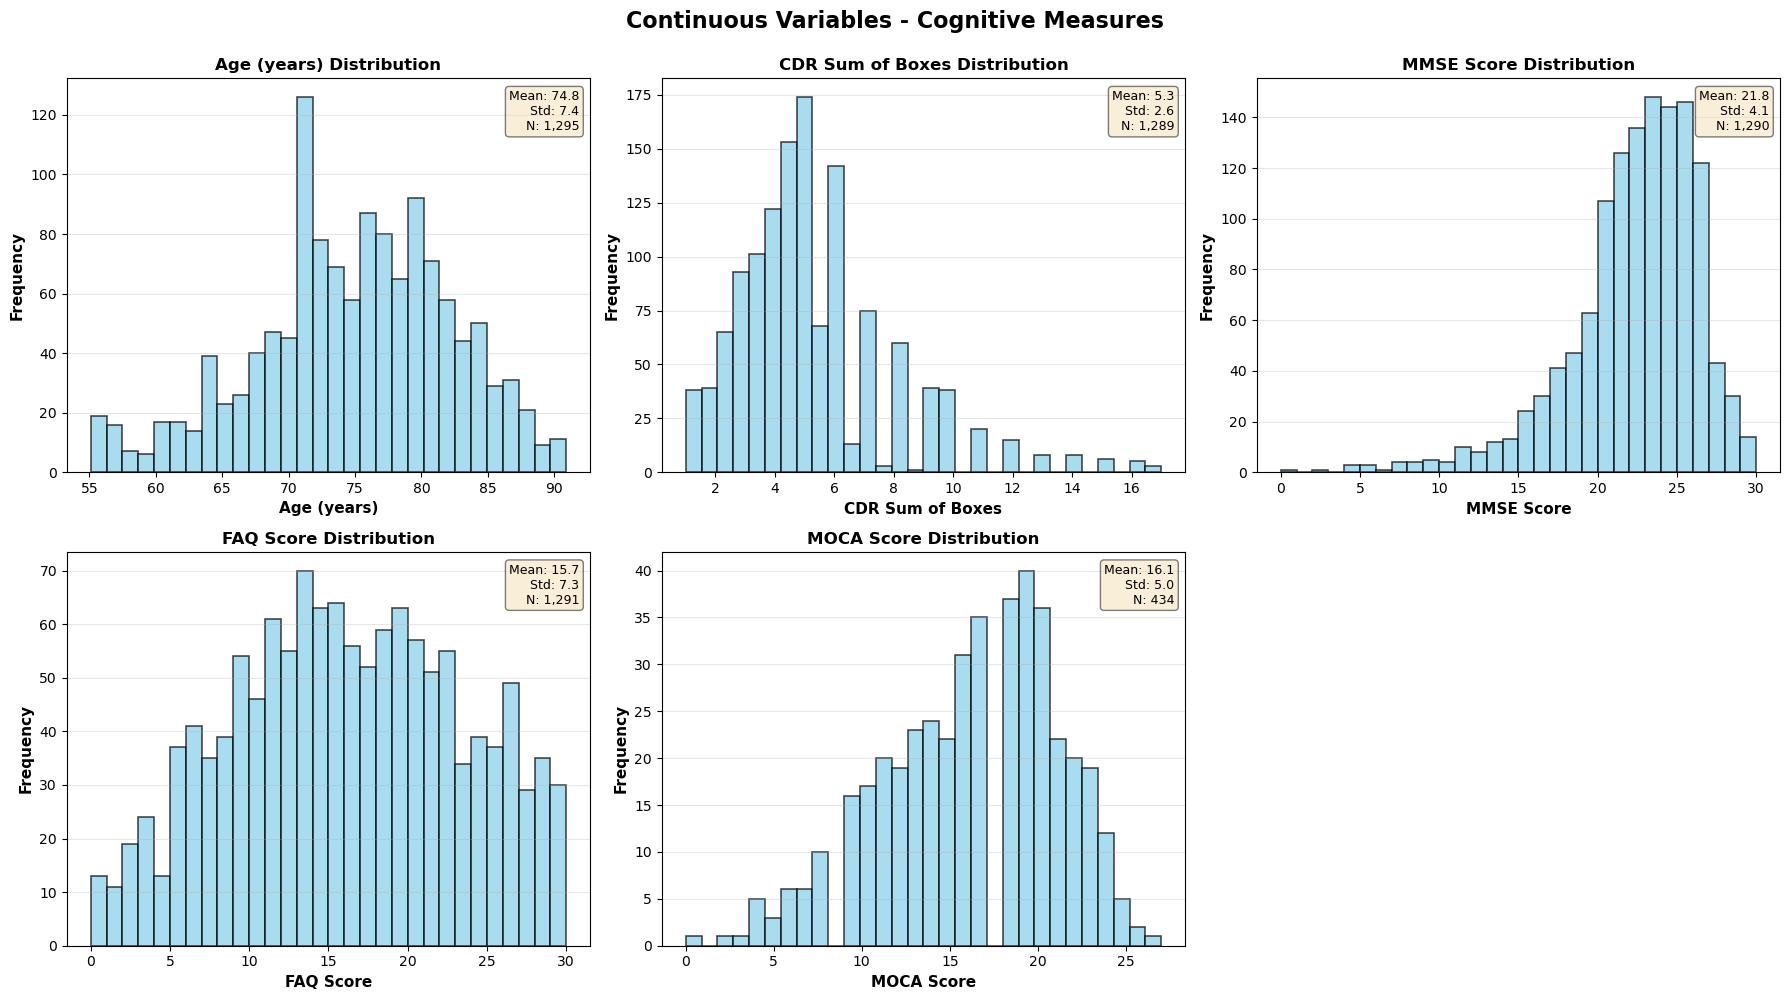

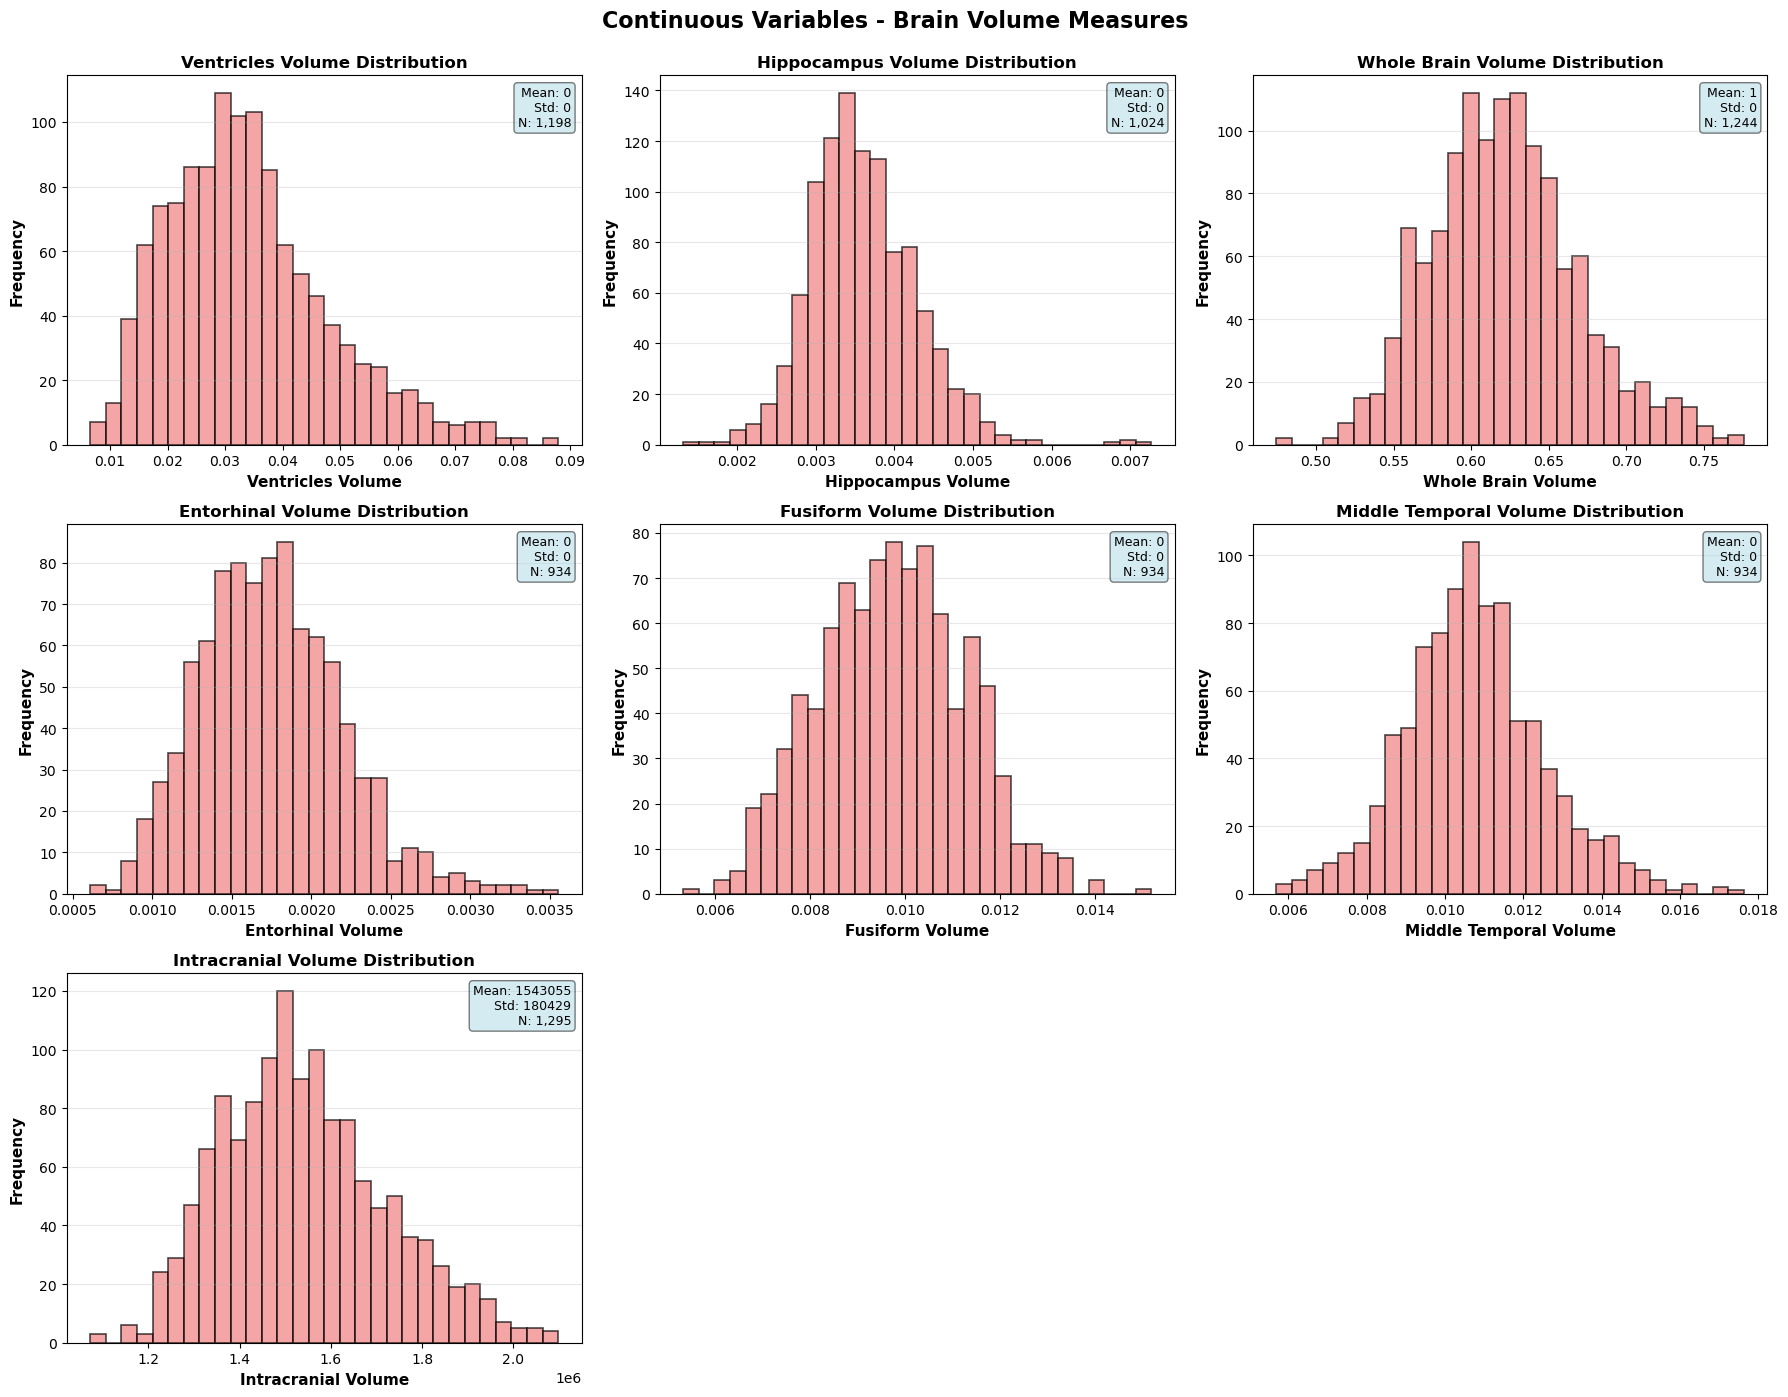


SUMMARY STATISTICS

📊 Categorical Variables:

Gender (PTGENDER):
  Male: 736 (56.8%)
  Female: 559 (43.2%)

Diagnosis (RS:DX_fill):
  Dementia: 1,295 (100.0%)

APOE4 Status (APOE4):
  1.0: 627 (48.4%)
  0.0: 413 (31.9%)
  2.0: 253 (19.5%)

📊 Continuous Variables:
               AGE        CDRSB         MMSE          FAQ        MOCA  \
count  1295.000000  1289.000000  1290.000000  1291.000000  434.000000   
mean     74.820618     5.344065    21.841085    15.659954   16.112903   
std       7.448140     2.605187     4.122863     7.261757    4.985769   
min      55.100000     1.000000     0.000000     0.000000    0.000000   
25%      70.700000     3.500000    20.000000    10.000000   13.000000   
50%      75.400000     5.000000    23.000000    16.000000   17.000000   
75%      80.150000     6.000000    25.000000    21.000000   20.000000   
max      90.900000    17.000000    30.000000    30.000000   27.000000   

        Ventricles  Hippocampus   WholeBrain  Entorhinal    Fusiform  \
count

In [54]:
# 6. Dementia 나이 분포
df_dementia = df[df['RS:DX_fill'] == 'Dementia']

print("="*80)
print("Dementia - 나이 분포")
print("="*80)

# 나이 데이터
age_data = df_dementia['AGE'].dropna()

# 통계량 출력
print(f"\n📊 나이 통계:")
print(f"  평균: {age_data.mean():.1f}세")
print(f"  표준편차: {age_data.std():.1f}세")
print(f"  최소값: {age_data.min():.1f}세")
print(f"  최대값: {age_data.max():.1f}세")
print(f"  중앙값: {age_data.median():.1f}세")
print(f"  데이터 개수: {len(age_data):,}명")

# 나이 분포 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(age_data, bins=30, color='lightcoral', edgecolor='black', linewidth=1.2, alpha=0.7)

ax.set_xlabel('나이 (세)', fontweight='bold', fontsize=12)
ax.set_ylabel('빈도', fontweight='bold', fontsize=12)
ax.set_title('Dementia - 나이 분포', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# 통계 정보 텍스트 박스
stats_text = f'평균: {age_data.mean():.1f}세\n표준편차: {age_data.std():.1f}세\nN: {len(age_data):,}명'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS - Dementia")
print("="*80)

# Define variables to plot
variables = {
    'Categorical': {
        'PTGENDER': 'Gender',
        'RS:DX_fill': 'Diagnosis',
        'APOE4': 'APOE4 Status'
    },
    'Continuous': {
        'AGE': 'Age (years)',
        'CDRSB': 'CDR Sum of Boxes',
        'MMSE': 'MMSE Score',
        'FAQ': 'FAQ Score',
        'MOCA': 'MOCA Score',
        'Ventricles': 'Ventricles Volume',
        'Hippocampus': 'Hippocampus Volume',
        'WholeBrain': 'Whole Brain Volume',
        'Entorhinal': 'Entorhinal Volume',
        'Fusiform': 'Fusiform Volume',
        'MidTemp': 'Middle Temporal Volume',
        'ICV': 'Intracranial Volume'
    }
}

# ============================================================================
# PLOT 1: Categorical Variables
# ============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold', y=1.02)

for idx, (var, label) in enumerate(variables['Categorical'].items()):
    ax = axes1[idx]

    # Count values
    value_counts = df_dementia[var].value_counts().sort_index()

    # Create bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values,
                   color=sns.color_palette('Set2', len(value_counts)),
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{label} Distribution', fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Continuous Variables (Part 1 - Cognitive Scores)
# ============================================================================
cognitive_vars = ['AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA']
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

fig2.suptitle('Continuous Variables - Cognitive Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(cognitive_vars):
    ax = axes2[idx]

    # Remove NaN values for plotting
    data = df_dementia[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='skyblue', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.1f}\nStd: {data.std():.1f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           fontsize=9)

# Remove extra subplot
axes2[5].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Continuous Variables (Part 2 - Brain Volumes)
# ============================================================================
brain_vars = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
              'Fusiform', 'MidTemp', 'ICV']
fig3, axes3 = plt.subplots(3, 3, figsize=(18, 14))
axes3 = axes3.flatten()

fig3.suptitle('Continuous Variables - Brain Volume Measures', fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(brain_vars):
    ax = axes3[idx]

    # Remove NaN values for plotting
    data = df_dementia[var].dropna()

    # Create histogram
    ax.hist(data, bins=30, color='lightcoral', edgecolor='black',
           linewidth=1.2, alpha=0.7)

    ax.set_xlabel(variables['Continuous'][var], fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{variables["Continuous"][var]} Distribution',
                fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f'Mean: {data.mean():.0f}\nStd: {data.std():.0f}\nN: {len(data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
           fontsize=9)

# Remove extra subplots
for i in range(len(brain_vars), 9):
    axes3[i].remove()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 Categorical Variables:")
for var, label in variables['Categorical'].items():
    print(f"\n{label} ({var}):")
    value_counts = df_dementia[var].value_counts()
    for val, count in value_counts.items():
        pct = 100 * count / len(df_dementia)
        print(f"  {val}: {count:,} ({pct:.1f}%)")

print("\n📊 Continuous Variables:")
continuous_all = list(variables['Continuous'].keys())
stats_df = df_dementia[continuous_all].describe()
print(stats_df)

MMSE VARIANCE ANALYSIS BY DIAGNOSIS

📊 MMSE Statistics by Diagnosis:
            Count   Mean   Std  Variance   Min   25%  Median   75%   Max
RS:DX_fill                                                              
CN           1736  29.04  1.19      1.41  22.0  29.0    29.0  30.0  30.0
Dementia     1290  21.84  4.12     17.00   0.0  20.0    23.0  25.0  30.0
MCI          1475  27.04  2.43      5.90   8.0  26.0    27.0  29.0  30.0


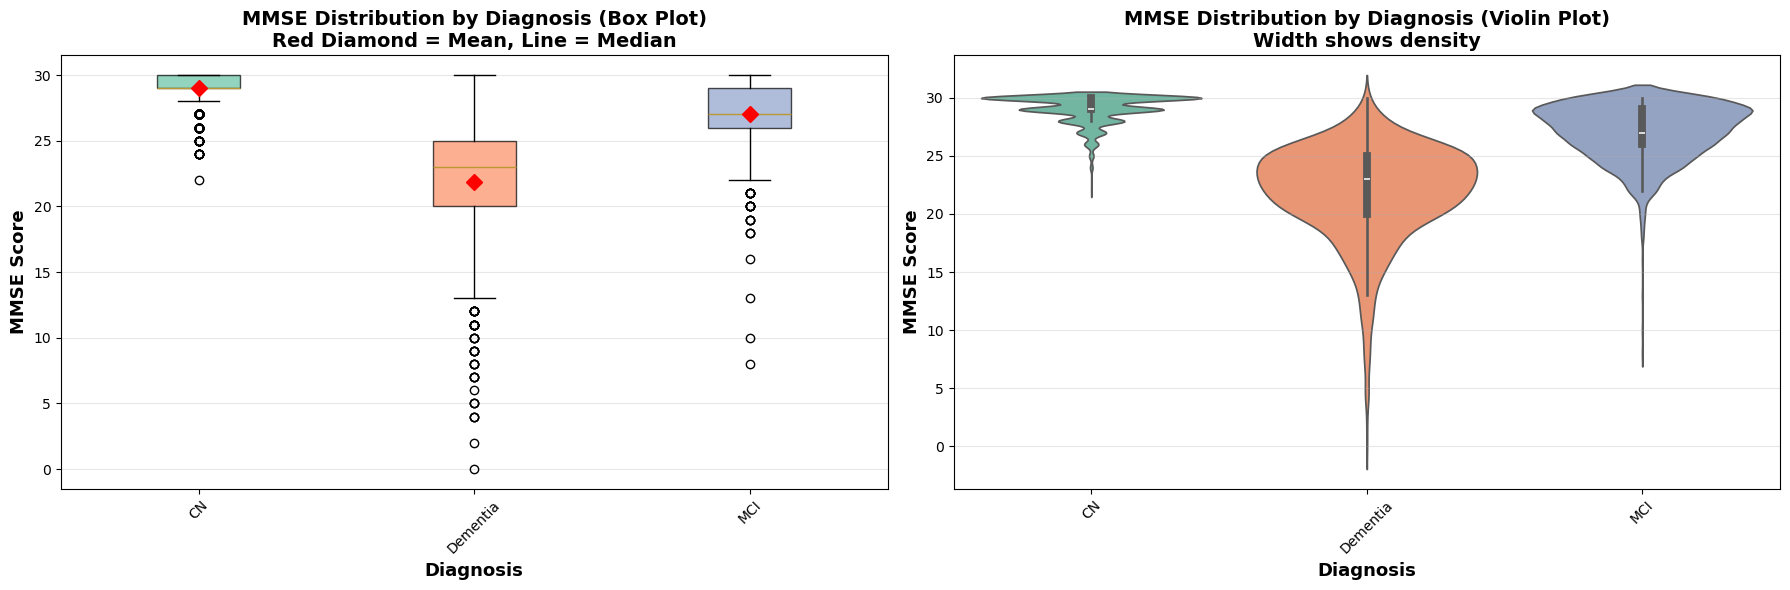

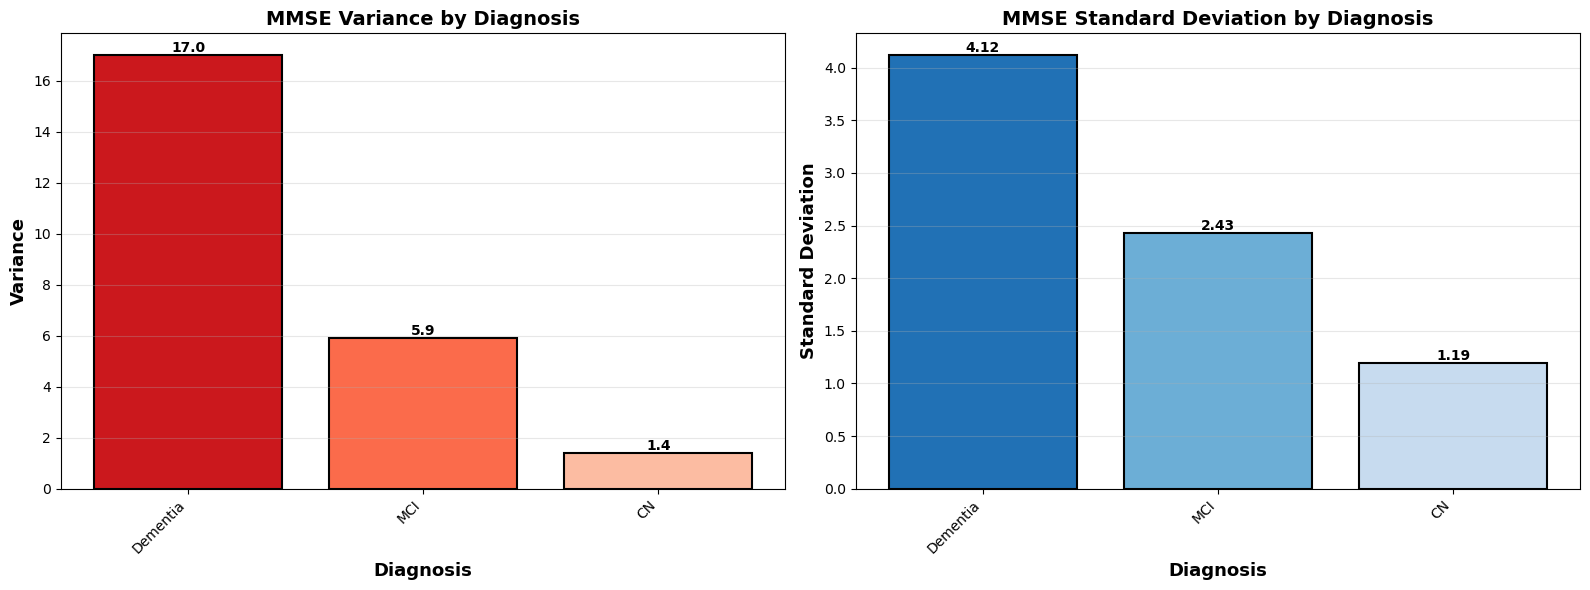

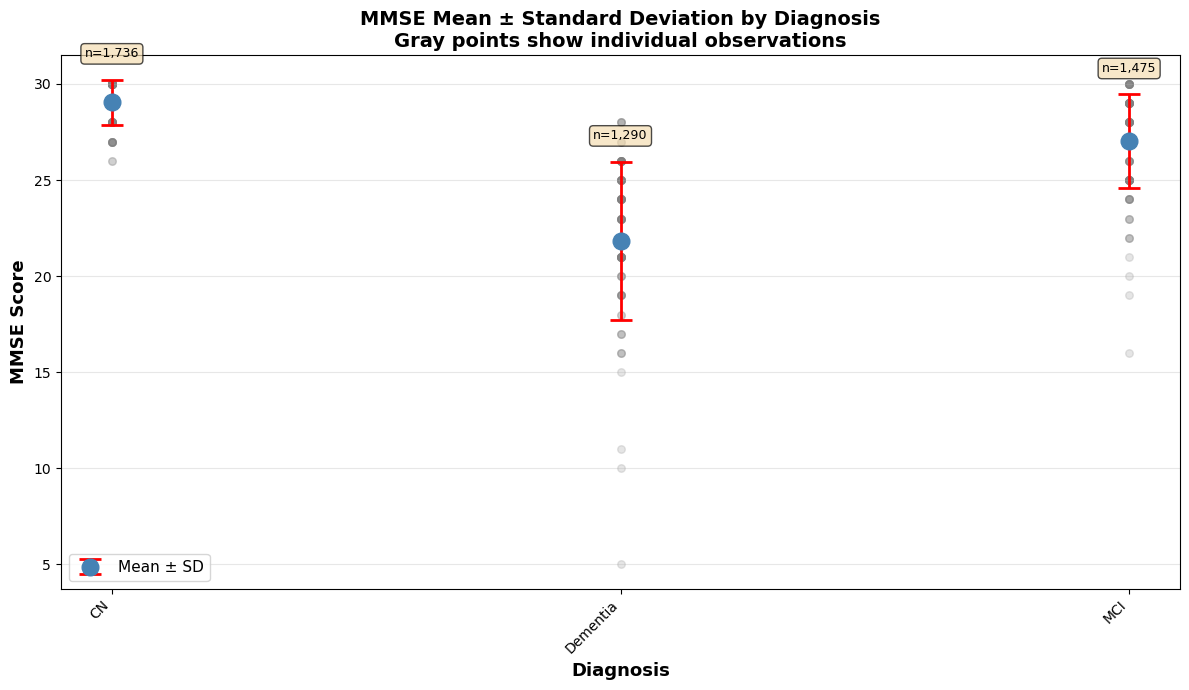


STATISTICAL TEST: Levene's Test for Homogeneity of Variance

Levene's Test Statistic: 480.3943
P-value: 8.1511e-190

✓ Result: Variances are significantly different across diagnosis groups (p < 0.05)

INTERPRETATION

📊 Variance indicates the spread/dispersion of MMSE scores:
  • Higher variance = More heterogeneous cognitive performance
  • Lower variance = More homogeneous cognitive performance

This can reveal:
  • Which diagnostic groups show more variability in cognitive function
  • Whether certain diagnoses have more predictable cognitive profiles


In [55]:
# MMSE Variance by Diagnosis

print("="*80)
print("MMSE VARIANCE ANALYSIS BY DIAGNOSIS")
print("="*80)

# Calculate statistics by diagnosis
mmse_by_dx = df.groupby('RS:DX_fill')['MMSE'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Variance', 'var'),
    ('Min', 'min'),
    ('25%', lambda x: x.quantile(0.25)),
    ('Median', 'median'),
    ('75%', lambda x: x.quantile(0.75)),
    ('Max', 'max')
]).round(2)

print("\n📊 MMSE Statistics by Diagnosis:")
print(mmse_by_dx)

# ============================================================================
# PLOT 1: Box Plot + Violin Plot (side by side)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot
ax1 = axes[0]
box_parts = ax1.boxplot([df[df['RS:DX_fill'] == dx]['MMSE'].dropna()
                          for dx in df['RS:DX_fill'].unique()],
                         labels=df['RS:DX_fill'].unique(),
                         patch_artist=True,
                         showmeans=True,
                         meanprops=dict(marker='D', markerfacecolor='red',
                                       markeredgecolor='red', markersize=8))

# Color the boxes
colors = sns.color_palette('Set2', len(df['RS:DX_fill'].unique()))
for patch, color in zip(box_parts['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xlabel('Diagnosis', fontweight='bold', fontsize=13)
ax1.set_ylabel('MMSE Score', fontweight='bold', fontsize=13)
ax1.set_title('MMSE Distribution by Diagnosis (Box Plot)\nRed Diamond = Mean, Line = Median',
             fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Violin Plot
ax2 = axes[1]
sns.violinplot(data=df, x='RS:DX_fill', y='MMSE', ax=ax2, palette='Set2')
ax2.set_xlabel('Diagnosis', fontweight='bold', fontsize=13)
ax2.set_ylabel('MMSE Score', fontweight='bold', fontsize=13)
ax2.set_title('MMSE Distribution by Diagnosis (Violin Plot)\nWidth shows density',
             fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Variance Comparison Bar Plot
# ============================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Plot 2a: Variance comparison
ax2a = axes2[0]
variance_data = mmse_by_dx['Variance'].sort_values(ascending=False)
bars = ax2a.bar(range(len(variance_data)), variance_data.values,
                color=sns.color_palette('Reds_r', len(variance_data)),
                edgecolor='black', linewidth=1.5)

ax2a.set_xlabel('Diagnosis', fontweight='bold', fontsize=13)
ax2a.set_ylabel('Variance', fontweight='bold', fontsize=13)
ax2a.set_title('MMSE Variance by Diagnosis', fontweight='bold', fontsize=14)
ax2a.set_xticks(range(len(variance_data)))
ax2a.set_xticklabels(variance_data.index, rotation=45, ha='right')
ax2a.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2a.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2b: Standard Deviation comparison
ax2b = axes2[1]
std_data = mmse_by_dx['Std'].sort_values(ascending=False)
bars2 = ax2b.bar(range(len(std_data)), std_data.values,
                 color=sns.color_palette('Blues_r', len(std_data)),
                 edgecolor='black', linewidth=1.5)

ax2b.set_xlabel('Diagnosis', fontweight='bold', fontsize=13)
ax2b.set_ylabel('Standard Deviation', fontweight='bold', fontsize=13)
ax2b.set_title('MMSE Standard Deviation by Diagnosis', fontweight='bold', fontsize=14)
ax2b.set_xticks(range(len(std_data)))
ax2b.set_xticklabels(std_data.index, rotation=45, ha='right')
ax2b.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2b.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 3: Mean ± SD Comparison
# ============================================================================
fig3, ax3 = plt.subplots(1, 1, figsize=(12, 7))

diagnoses = mmse_by_dx.index
means = mmse_by_dx['Mean'].values
stds = mmse_by_dx['Std'].values
counts = mmse_by_dx['Count'].values

x_pos = np.arange(len(diagnoses))

# Plot means with error bars (±SD)
ax3.errorbar(x_pos, means, yerr=stds, fmt='o', markersize=12,
            capsize=8, capthick=2, linewidth=2,
            color='steelblue', ecolor='red',
            label='Mean ± SD')

# Add points for individual data (small sample)
for i, dx in enumerate(diagnoses):
    dx_data = df[df['RS:DX_fill'] == dx]['MMSE'].dropna()
    # Sample if too many points
    if len(dx_data) > 100:
        dx_data = dx_data.sample(100, random_state=42)
    ax3.scatter([i] * len(dx_data), dx_data, alpha=0.2, s=30, color='gray')

ax3.set_xlabel('Diagnosis', fontweight='bold', fontsize=13)
ax3.set_ylabel('MMSE Score', fontweight='bold', fontsize=13)
ax3.set_title('MMSE Mean ± Standard Deviation by Diagnosis\nGray points show individual observations',
             fontweight='bold', fontsize=14)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(diagnoses, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
ax3.legend(fontsize=11)

# Add count labels
for i, (mean, count) in enumerate(zip(means, counts)):
    ax3.text(i, mean + stds[i] + 1, f'n={int(count):,}',
            ha='center', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================================
# Statistical Test: Levene's Test for Homogeneity of Variance
# ============================================================================
from scipy import stats

print("\n" + "="*80)
print("STATISTICAL TEST: Levene's Test for Homogeneity of Variance")
print("="*80)

# Prepare data for Levene's test
groups = [df[df['RS:DX_fill'] == dx]['MMSE'].dropna() for dx in df['RS:DX_fill'].unique()]
levene_stat, levene_p = stats.levene(*groups)

print(f"\nLevene's Test Statistic: {levene_stat:.4f}")
print(f"P-value: {levene_p:.4e}")

if levene_p < 0.05:
    print("\n✓ Result: Variances are significantly different across diagnosis groups (p < 0.05)")
else:
    print("\n✓ Result: No significant difference in variances across diagnosis groups (p ≥ 0.05)")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\n📊 Variance indicates the spread/dispersion of MMSE scores:")
print("  • Higher variance = More heterogeneous cognitive performance")
print("  • Lower variance = More homogeneous cognitive performance")
print("\nThis can reveal:")
print("  • Which diagnostic groups show more variability in cognitive function")
print("  • Whether certain diagnoses have more predictable cognitive profiles")


CORRELATION ANALYSIS

📊 Encoding categorical variables...
  PTGENDER: {'Male': 1, 'Female': 0}
  RS:DX_fill mapping:
    CN: 0
    Dementia: 1
    MCI: 2
  APOE4: Already numeric (values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(nan)])

📊 Converting biomarkers to numeric...
  ABETA_bl: 2,328 non-null (51.6%)
  TAU_bl: 2,749 non-null (61.0%)
  PTAU_bl: 2,744 non-null (60.9%)
  FDG_bl: 2,868 non-null (63.6%)

📊 Calculating correlation matrix...
  Shape: (18, 18)
  Variables: 18


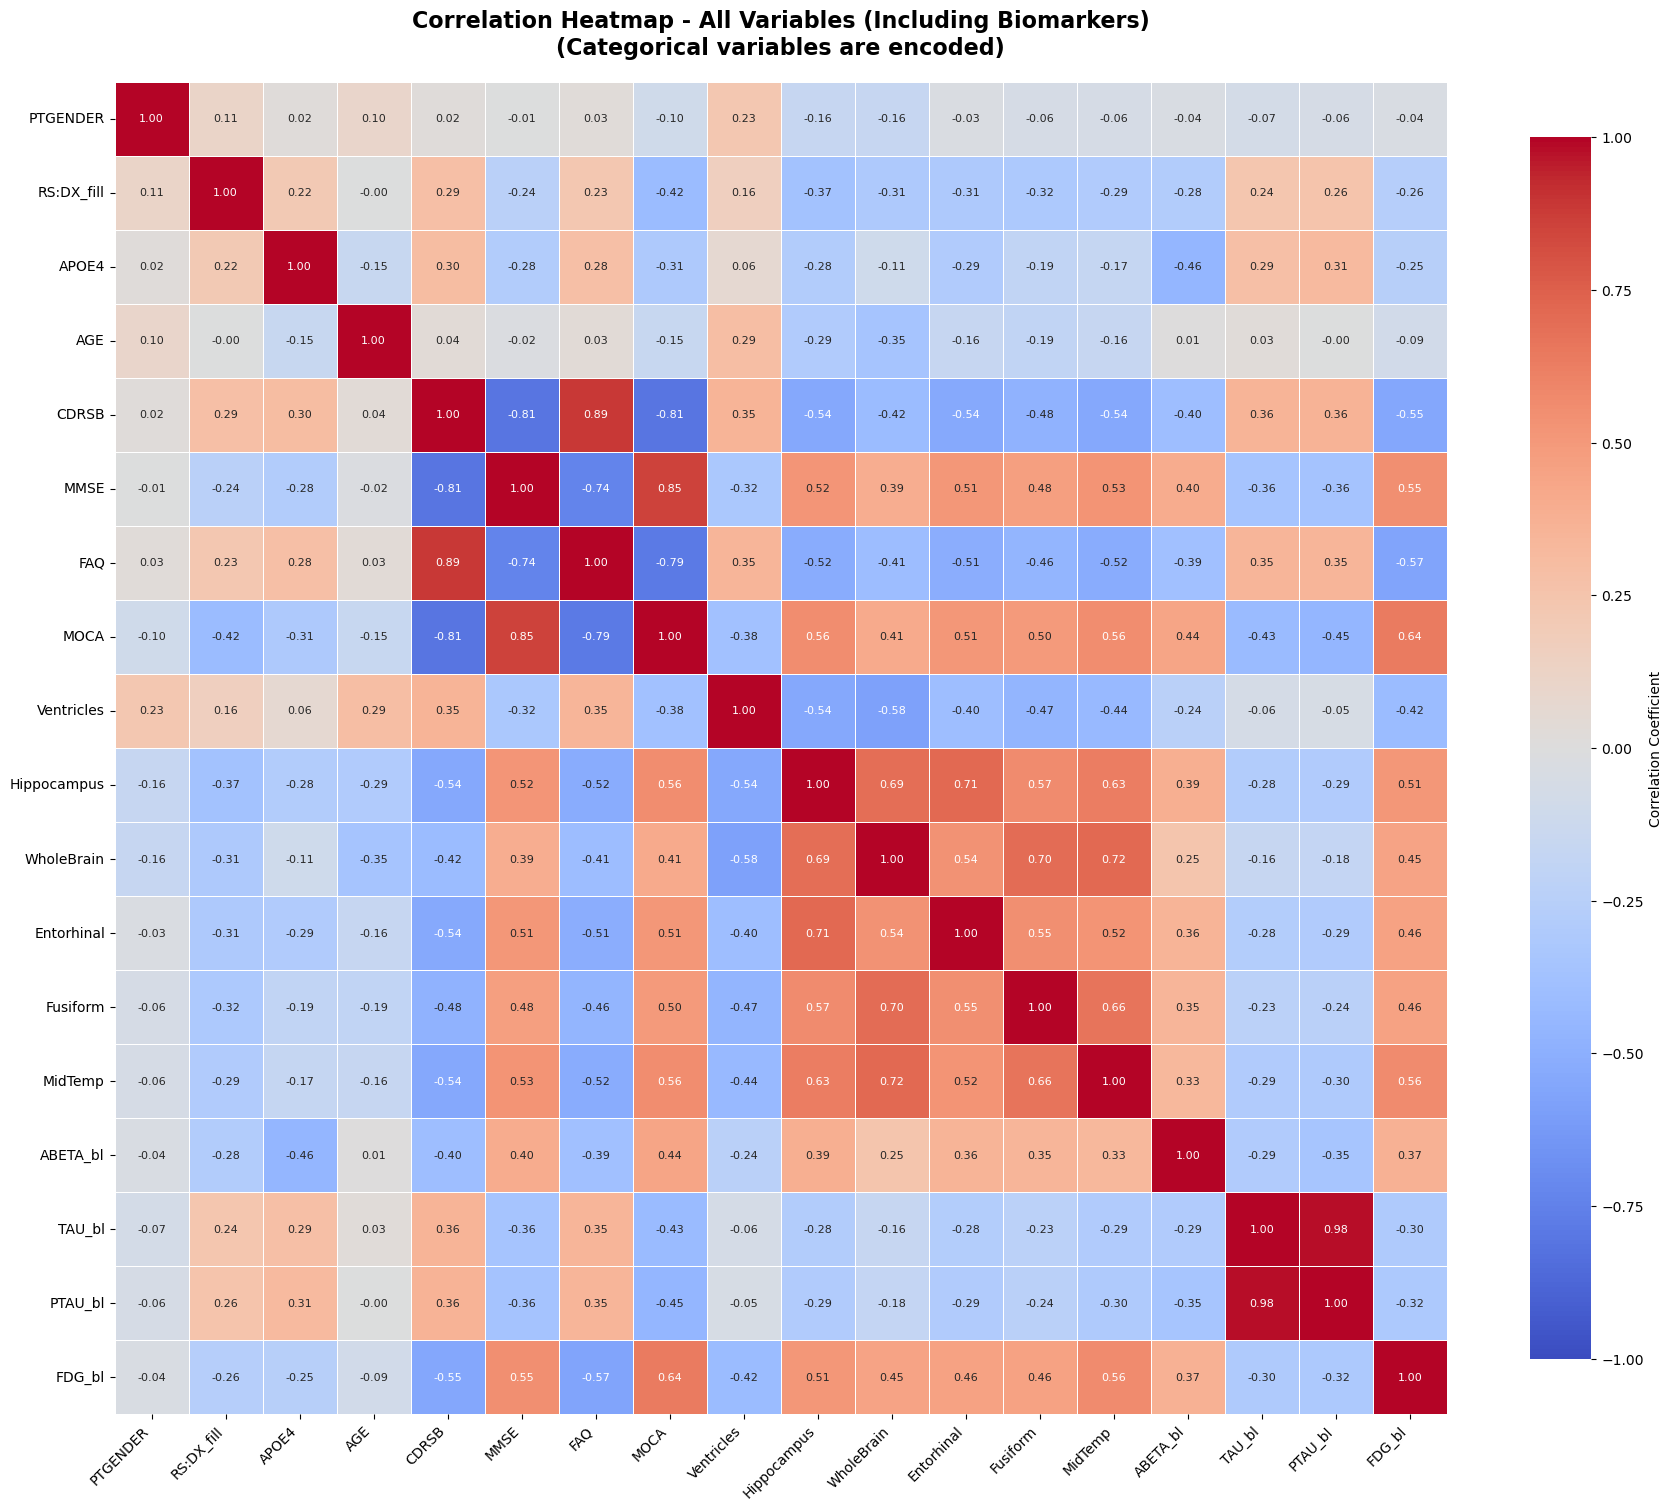

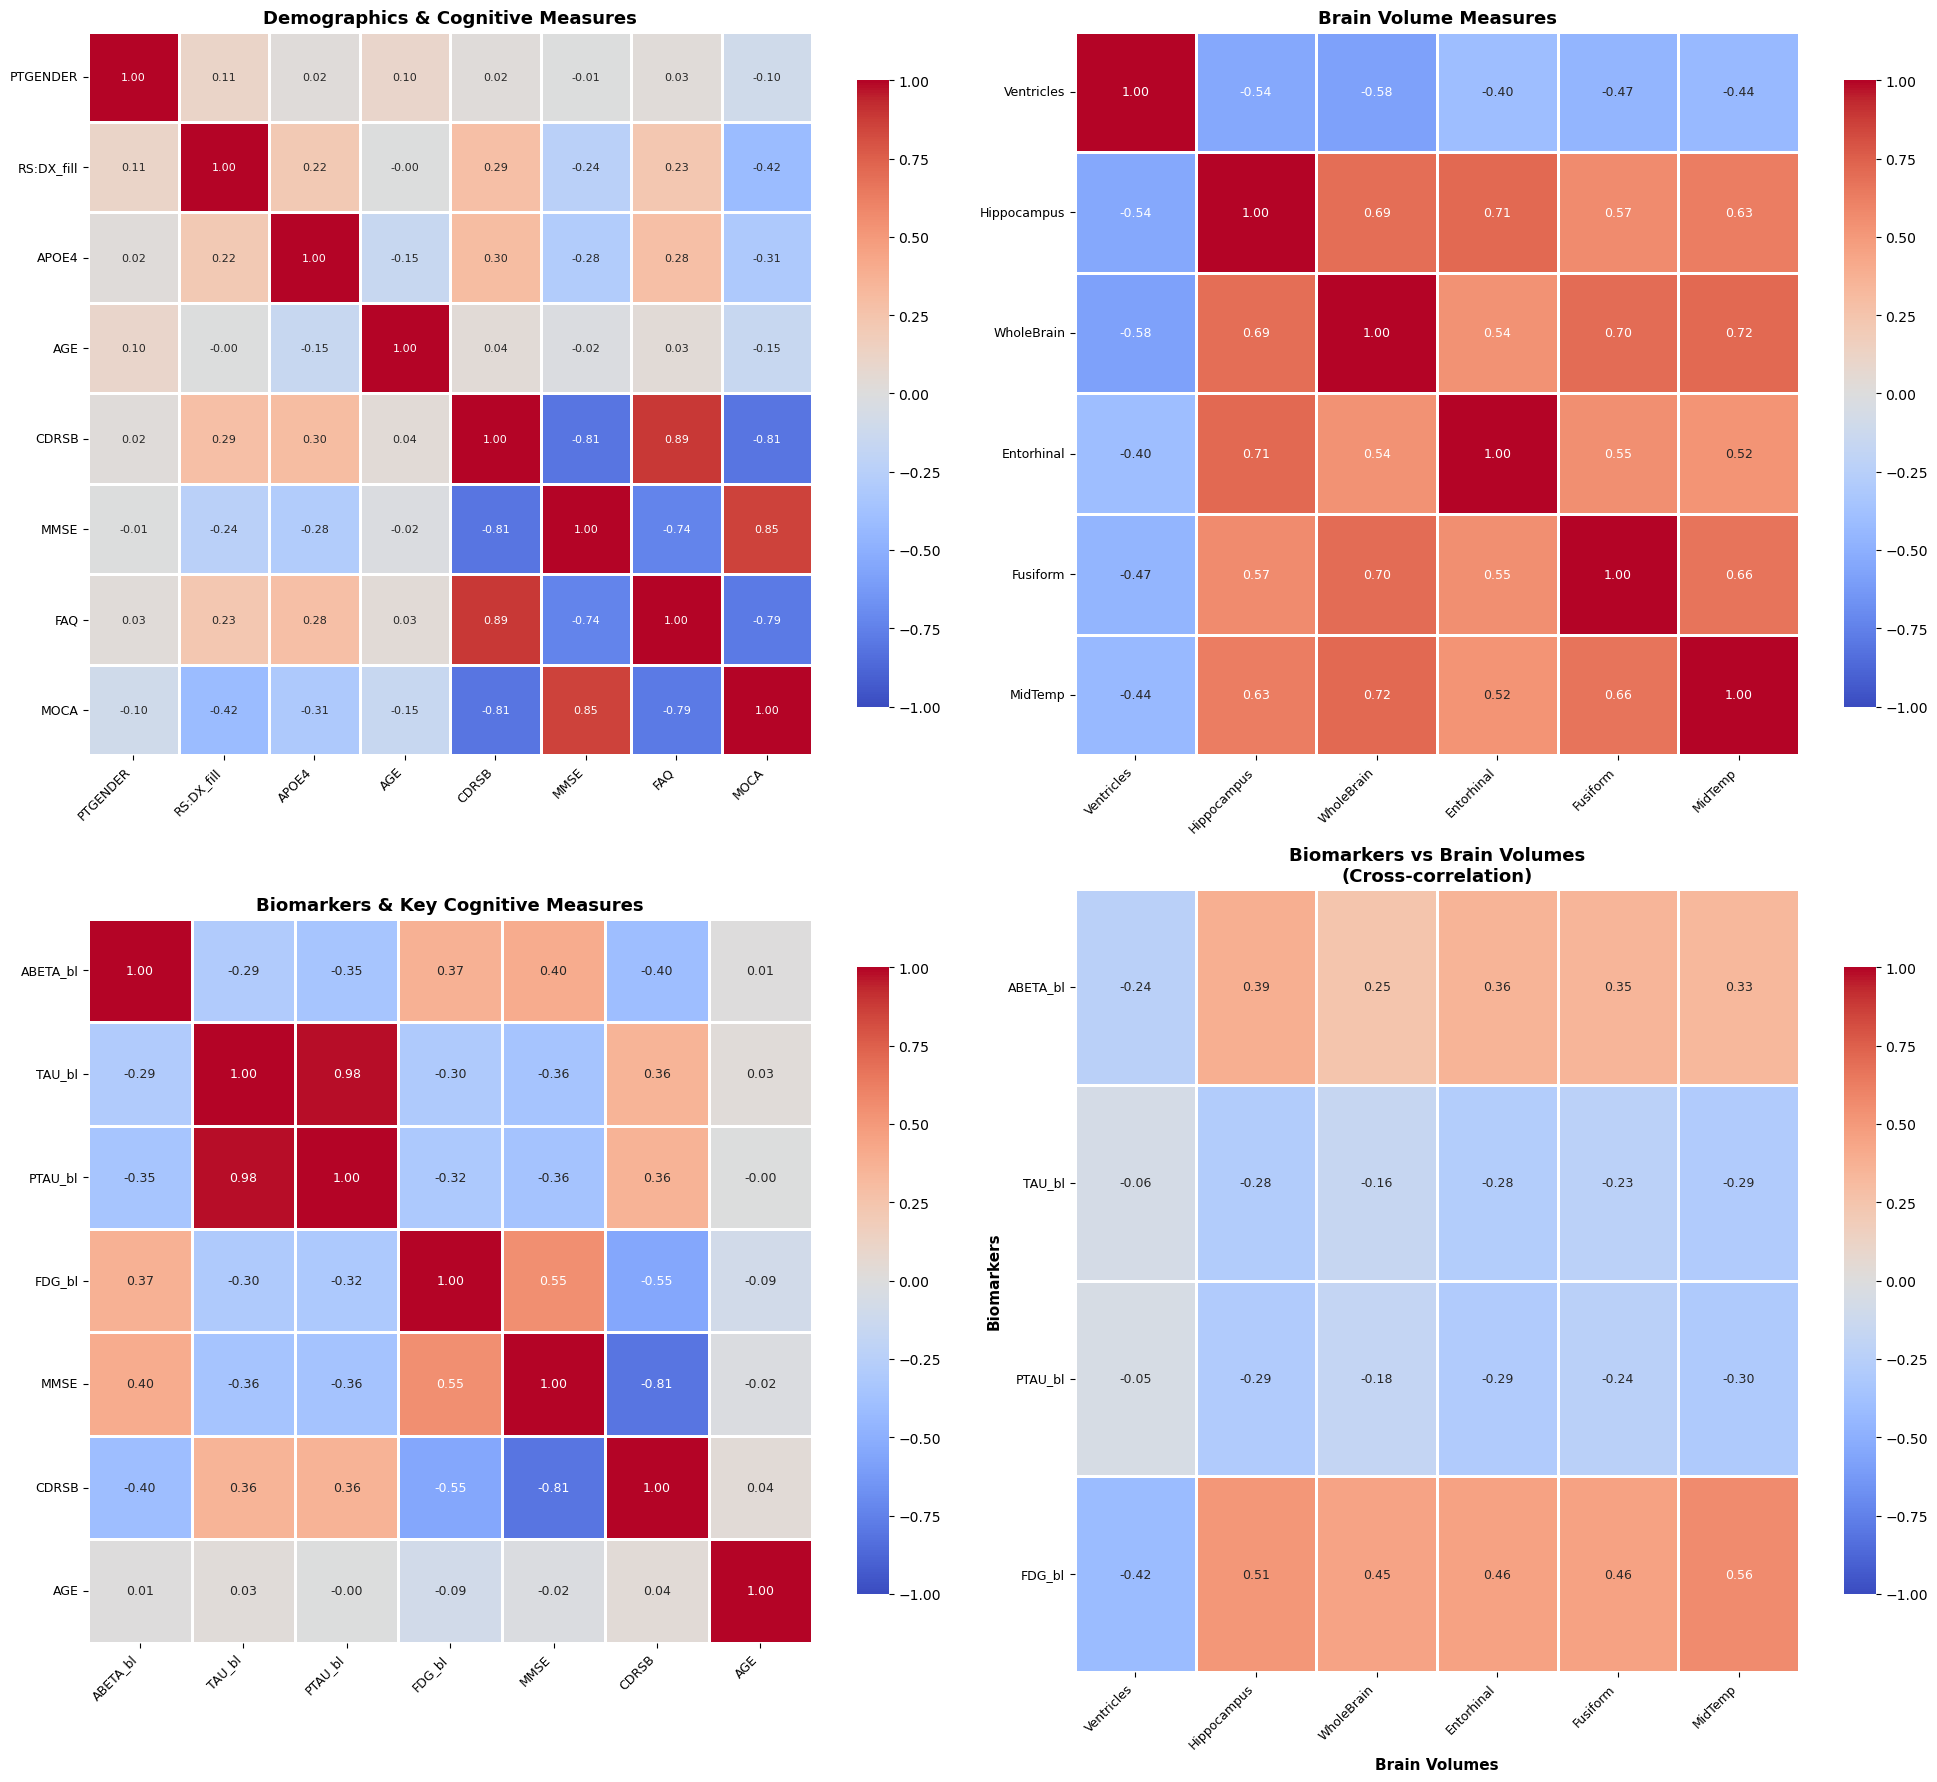


TOP CORRELATIONS (|r| > 0.3)

Found 87 strong correlations (threshold: |r| > 0.3)

🔵 Strong Positive Correlations (r > 0.3):
  TAU_bl          ↔ PTAU_bl        : r = +0.981
  CDRSB           ↔ FAQ            : r = +0.886
  MMSE            ↔ MOCA           : r = +0.854
  WholeBrain      ↔ MidTemp        : r = +0.718
  Hippocampus     ↔ Entorhinal     : r = +0.714
  WholeBrain      ↔ Fusiform       : r = +0.703
  Hippocampus     ↔ WholeBrain     : r = +0.689
  Fusiform        ↔ MidTemp        : r = +0.665
  MOCA            ↔ FDG_bl         : r = +0.639
  Hippocampus     ↔ MidTemp        : r = +0.632
  Hippocampus     ↔ Fusiform       : r = +0.569
  MidTemp         ↔ FDG_bl         : r = +0.564
  MOCA            ↔ Hippocampus    : r = +0.561
  MOCA            ↔ MidTemp        : r = +0.560
  MMSE            ↔ FDG_bl         : r = +0.551
  Entorhinal      ↔ Fusiform       : r = +0.548
  WholeBrain      ↔ Entorhinal     : r = +0.537
  MMSE            ↔ MidTemp        : r = +0.527
  Entorhin

In [56]:
# Correlation Heatmap Analysis

print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select variables for correlation analysis (including biomarkers!)
variables = ['PTGENDER', 'RS:DX_fill', 'APOE4',
             'AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA',
             'Ventricles', 'Hippocampus', 'WholeBrain',
             'Entorhinal', 'Fusiform', 'MidTemp',
             'ABETA_bl', 'TAU_bl', 'PTAU_bl', 'FDG_bl']

# Create a copy for encoding
df_corr = df[variables].copy()

# Encode categorical variables
print("\n📊 Encoding categorical variables...")

# Gender: Male=1, Female=0
gender_map = {'Male': 1, 'Female': 0}
df_corr['PTGENDER'] = df_corr['PTGENDER'].map(gender_map)
print(f"  PTGENDER: {gender_map}")

# Diagnosis: Label encoding
dx_categories = df_corr['RS:DX_fill'].unique()
dx_map = {dx: i for i, dx in enumerate(sorted(dx_categories))}
df_corr['RS:DX_fill'] = df_corr['RS:DX_fill'].map(dx_map)
print(f"  RS:DX_fill mapping:")
for dx, code in sorted(dx_map.items(), key=lambda x: x[1]):
    print(f"    {dx}: {code}")

# APOE4 is already numeric
print(f"  APOE4: Already numeric (values: {sorted(df_corr['APOE4'].unique())})")

# Convert biomarkers to numeric
print("\n📊 Converting biomarkers to numeric...")
biomarker_vars = ['ABETA_bl', 'TAU_bl', 'PTAU_bl', 'FDG_bl']
for var in biomarker_vars:
    df_corr[var] = pd.to_numeric(df_corr[var], errors='coerce')
    non_null = df_corr[var].notna().sum()
    print(f"  {var}: {non_null:,} non-null ({100*non_null/len(df_corr):.1f}%)")

# Calculate correlation matrix
print("\n📊 Calculating correlation matrix...")
corr_matrix = df_corr.corr()

print(f"  Shape: {corr_matrix.shape}")
print(f"  Variables: {len(variables)}")

# ============================================================================
# PLOT 1: Full Correlation Heatmap
# ============================================================================
fig1, ax1 = plt.subplots(1, 1, figsize=(18, 16))

# Create heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=ax1,
            annot_kws={'fontsize': 8})

ax1.set_title('Correlation Heatmap - All Variables (Including Biomarkers)\n(Categorical variables are encoded)',
             fontsize=16, fontweight='bold', pad=20)

# Rotate labels
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Focused Heatmaps
# ============================================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 18))
axes2 = axes2.flatten()

# Group 1: Demographics & Cognitive
group1_vars = ['PTGENDER', 'RS:DX_fill', 'APOE4', 'AGE', 'CDRSB', 'MMSE', 'FAQ', 'MOCA']
corr1 = df_corr[group1_vars].corr()

sns.heatmap(corr1, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes2[0], annot_kws={'fontsize': 8})
axes2[0].set_title('Demographics & Cognitive Measures', fontsize=13, fontweight='bold')
axes2[0].set_xticklabels(axes2[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes2[0].set_yticklabels(axes2[0].get_yticklabels(), rotation=0, fontsize=9)

# Group 2: Brain volumes
brain_vars = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp']
corr2 = df_corr[brain_vars].corr()

sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes2[1], annot_kws={'fontsize': 9})
axes2[1].set_title('Brain Volume Measures', fontsize=13, fontweight='bold')
axes2[1].set_xticklabels(axes2[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes2[1].set_yticklabels(axes2[1].get_yticklabels(), rotation=0, fontsize=9)

# Group 3: Biomarkers (NEW!)
biomarker_group = biomarker_vars + ['MMSE', 'CDRSB', 'AGE']
corr3 = df_corr[biomarker_group].corr()

sns.heatmap(corr3, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes2[2], annot_kws={'fontsize': 9})
axes2[2].set_title('Biomarkers & Key Cognitive Measures', fontsize=13, fontweight='bold')
axes2[2].set_xticklabels(axes2[2].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes2[2].set_yticklabels(axes2[2].get_yticklabels(), rotation=0, fontsize=9)

# Group 4: Biomarkers vs Brain volumes (cross-correlation)
corr4 = df_corr[biomarker_vars + brain_vars].corr()
corr4_cross = corr4.loc[biomarker_vars, brain_vars]

sns.heatmap(corr4_cross, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes2[3], annot_kws={'fontsize': 9})
axes2[3].set_title('Biomarkers vs Brain Volumes\n(Cross-correlation)',
                   fontsize=13, fontweight='bold')
axes2[3].set_xlabel('Brain Volumes', fontsize=11, fontweight='bold')
axes2[3].set_ylabel('Biomarkers', fontsize=11, fontweight='bold')
axes2[3].set_xticklabels(axes2[3].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes2[3].set_yticklabels(axes2[3].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# Top Correlations Analysis
# ============================================================================
print("\n" + "="*80)
print("TOP CORRELATIONS (|r| > 0.3)")
print("="*80)

# Get upper triangle of correlation matrix (to avoid duplicates)
corr_unstacked = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

# Filter by threshold
threshold = 0.3
strong_corr = corr_unstacked[abs(corr_unstacked) > threshold]

print(f"\nFound {len(strong_corr)} strong correlations (threshold: |r| > {threshold})\n")

# Positive correlations
print("🔵 Strong Positive Correlations (r > 0.3):")
positive = strong_corr[strong_corr > threshold].sort_values(ascending=False)
for (var1, var2), corr_val in positive.items():
    print(f"  {var1:15s} ↔ {var2:15s}: r = {corr_val:+.3f}")

# Negative correlations
print("\n🔴 Strong Negative Correlations (r < -0.3):")
negative = strong_corr[strong_corr < -threshold].sort_values()
for (var1, var2), corr_val in negative.items():
    print(f"  {var1:15s} ↔ {var2:15s}: r = {corr_val:+.3f}")

# ============================================================================
# Key Insights - Biomarkers
# ============================================================================
print("\n" + "="*80)
print("KEY INSIGHTS - BIOMARKERS")
print("="*80)

for biomarker in biomarker_vars:
    bio_corrs = corr_matrix[biomarker].drop(biomarker_vars).sort_values(key=abs, ascending=False)
    print(f"\n📊 Top correlations with {biomarker}:")
    for var, corr_val in bio_corrs.head(5).items():
        print(f"  {var:15s}: r = {corr_val:+.3f}")

print("\n" + "="*80)


In [57]:
# ICV-Normalized Brain Volumes vs Cognitive Scores Correlation

print("="*80)
print("ICV-NORMALIZED BRAIN VOLUMES vs COGNITIVE SCORES CORRELATION")
print("="*80)

# ICV-normalized brain volumes
brain_volumes_norm = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp']

# Cognitive scores
cognitive_scores = ['MMSE', 'CDRSB', 'MOCA']

# Select relevant columns and create correlation matrix
selected_vars = brain_volumes_norm + cognitive_scores
df_selected = df[selected_vars].copy()

# Calculate correlation matrix
corr_matrix = df_selected.corr()

print("\n📊 Correlation Matrix:")
print(corr_matrix)

# ============================================================================
# Extract correlations between brain volumes and cognitive scores
# ============================================================================
print("\n" + "="*80)
print("BRAIN VOLUMES (ICV-normalized) vs COGNITIVE SCORES")
print("="*80)

# Create a focused correlation table
corr_brain_cog = corr_matrix.loc[brain_volumes_norm, cognitive_scores]

print("\n📊 Correlation Table (Brain Volumes × Cognitive Scores):")
print(corr_brain_cog)

# Print detailed results
print("\n" + "="*80)
print("DETAILED CORRELATIONS")
print("="*80)

for brain_vol in brain_volumes_norm:
    print(f"\n{brain_vol}:")
    for cog_score in cognitive_scores:
        corr_val = corr_brain_cog.loc[brain_vol, cog_score]
        print(f"  vs {cog_score:10s}: r = {corr_val:+.4f}")

# ============================================================================
# Summary: Strongest correlations
# ============================================================================
print("\n" + "="*80)
print("STRONGEST CORRELATIONS (by cognitive score)")
print("="*80)

for cog_score in cognitive_scores:
    print(f"\n📊 {cog_score}:")
    corr_sorted = corr_brain_cog[cog_score].sort_values(key=abs, ascending=False)
    for brain_vol, corr_val in corr_sorted.items():
        print(f"  {brain_vol:15s}: r = {corr_val:+.4f}")

print("\n" + "="*80)

ICV-NORMALIZED BRAIN VOLUMES vs COGNITIVE SCORES CORRELATION

📊 Correlation Matrix:
             Ventricles  Hippocampus  WholeBrain  Entorhinal  Fusiform  \
Ventricles     1.000000    -0.539758   -0.579620   -0.400250 -0.466261   
Hippocampus   -0.539758     1.000000    0.688670    0.714305  0.568858   
WholeBrain    -0.579620     0.688670    1.000000    0.537188  0.702805   
Entorhinal    -0.400250     0.714305    0.537188    1.000000  0.548345   
Fusiform      -0.466261     0.568858    0.702805    0.548345  1.000000   
MidTemp       -0.435491     0.631591    0.718360    0.524507  0.664581   
MMSE          -0.323421     0.516653    0.391345    0.511209  0.475841   
CDRSB          0.354215    -0.543186   -0.420001   -0.535802 -0.478524   
MOCA          -0.381569     0.561252    0.412394    0.509018  0.497986   

              MidTemp      MMSE     CDRSB      MOCA  
Ventricles  -0.435491 -0.323421  0.354215 -0.381569  
Hippocampus  0.631591  0.516653 -0.543186  0.561252  
WholeBrain   

BRAIN REGIONS DISTRIBUTION BY DIAGNOSIS


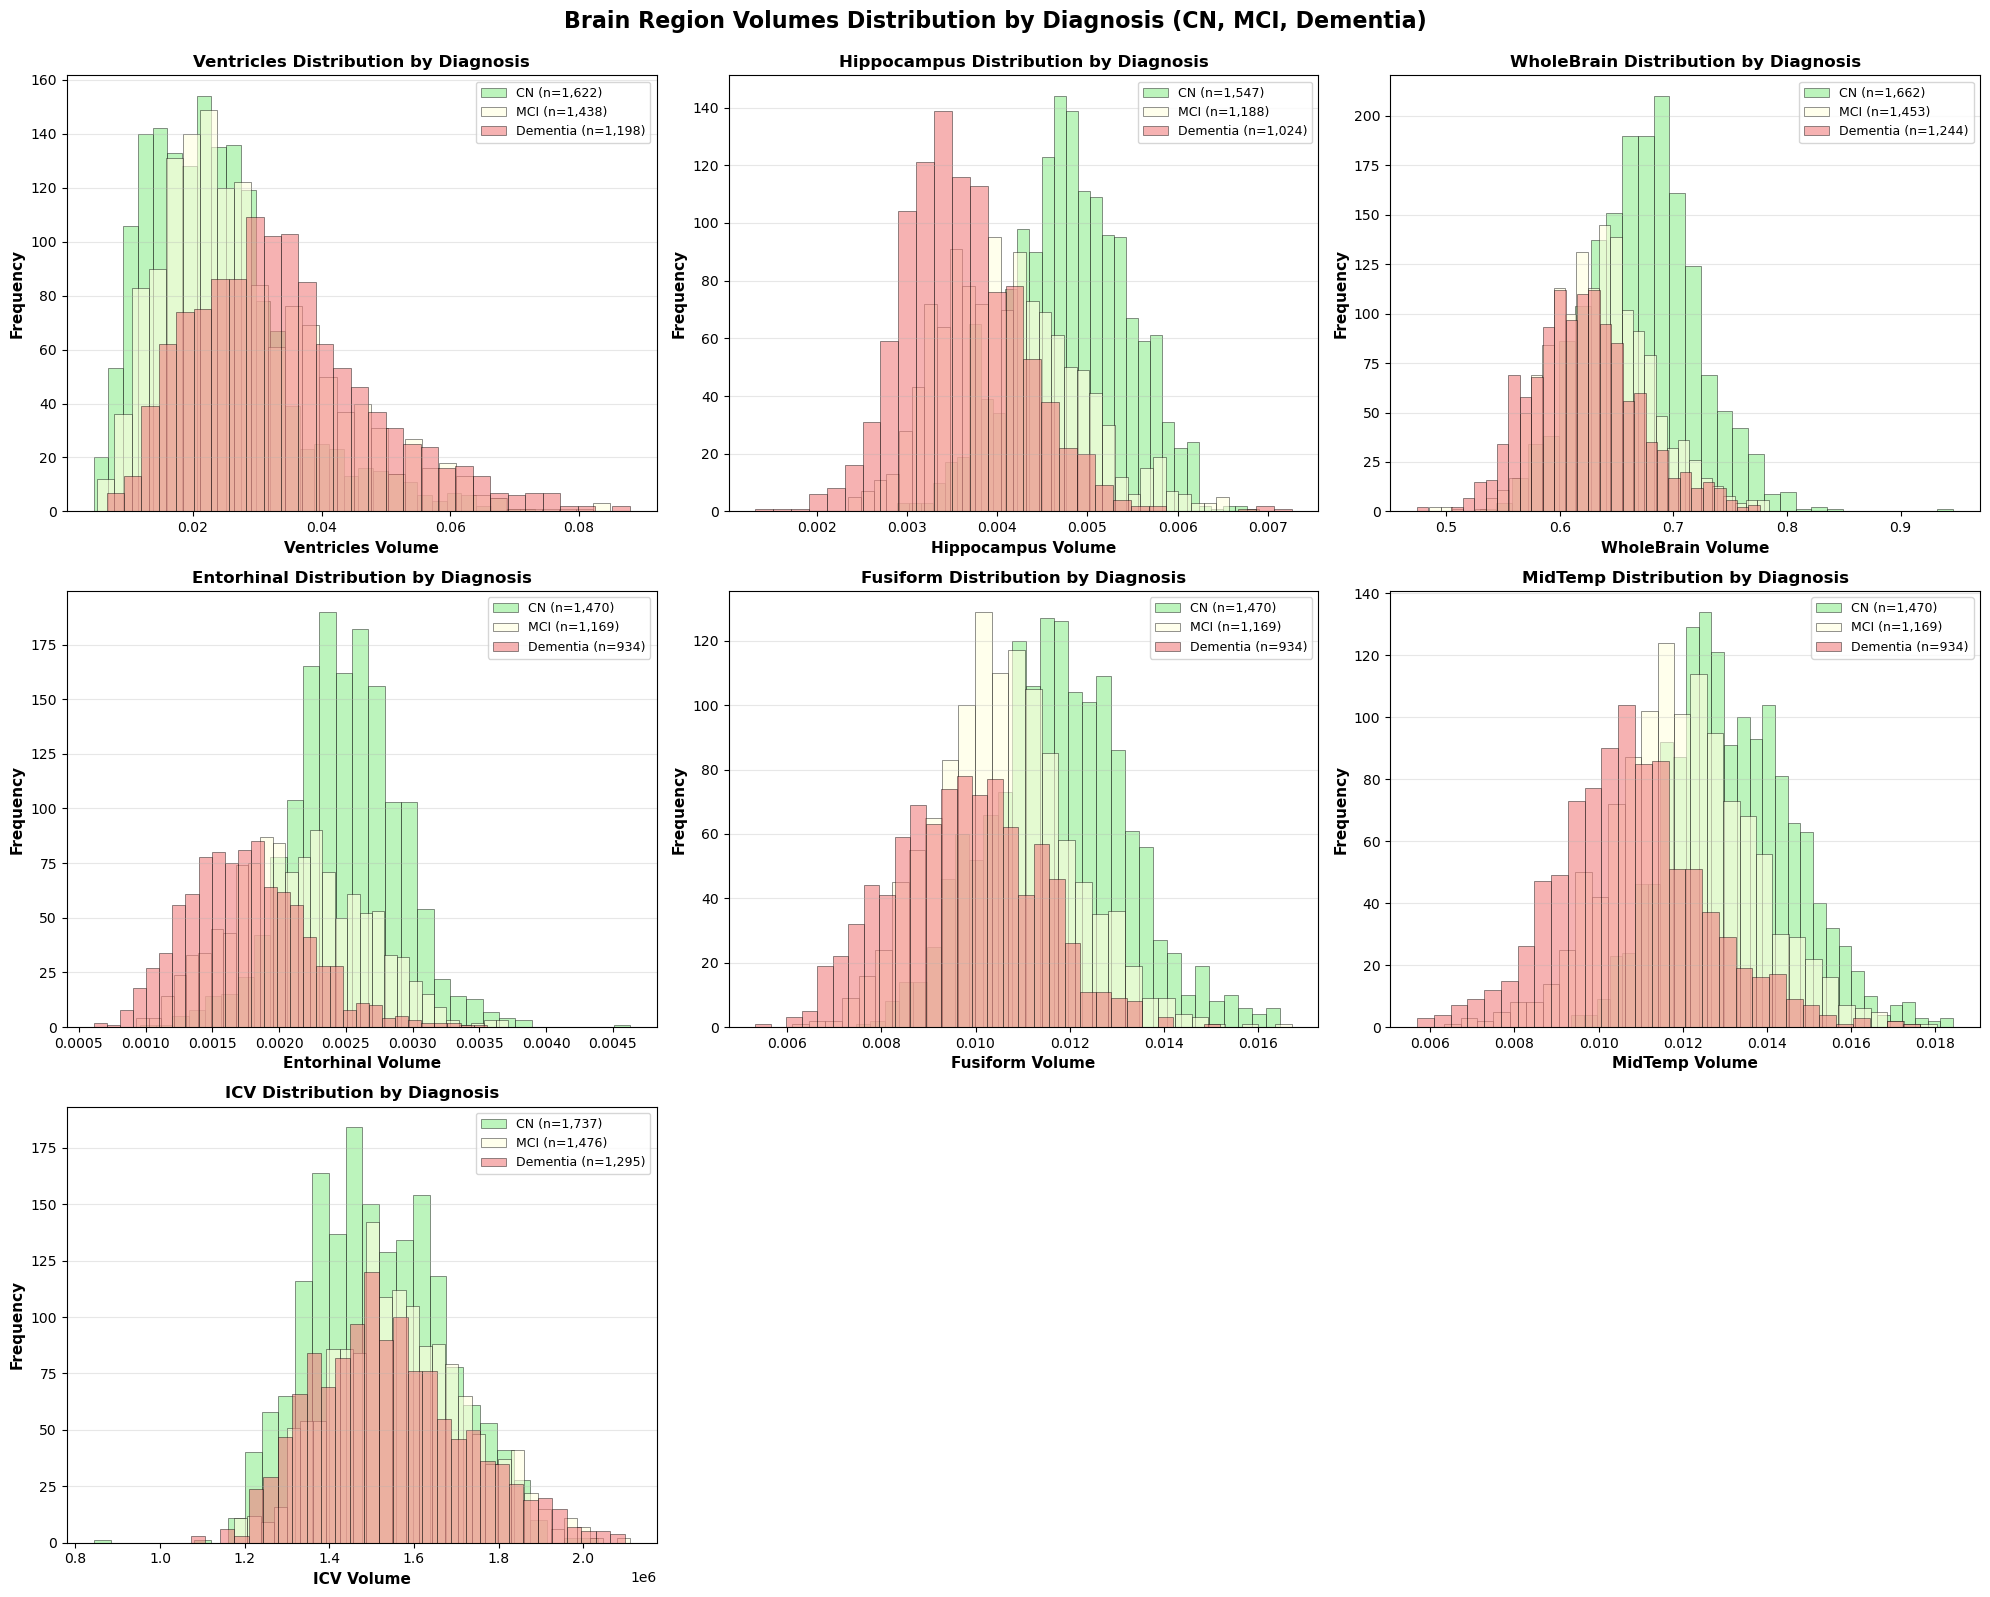


STATISTICS SUMMARY BY DIAGNOSIS

📊 Ventricles:
            count    mean     std     min  median     max
RS:DX_fill                                               
CN           1622  0.0234  0.0113  0.0046  0.0219  0.0732
Dementia     1198  0.0340  0.0140  0.0066  0.0319  0.0880
MCI          1438  0.0283  0.0133  0.0051  0.0253  0.0849

📊 Hippocampus:
            count    mean     std     min  median     max
RS:DX_fill                                               
CN           1547  0.0048  0.0006  0.0029  0.0048  0.0069
Dementia     1024  0.0036  0.0007  0.0013  0.0035  0.0073
MCI          1188  0.0041  0.0008  0.0023  0.0041  0.0066

📊 WholeBrain:
            count    mean     std     min  median     max
RS:DX_fill                                               
CN           1662  0.6732  0.0478  0.5299  0.6733  0.9462
Dementia     1244  0.6219  0.0473  0.4742  0.6194  0.7760
MCI          1453  0.6374  0.0444  0.4851  0.6360  0.7837

📊 Entorhinal:
            count    mean     std   

In [58]:
# Brain Regions Distribution by Diagnosis (CN, MCI, Dementia)

print("="*80)
print("BRAIN REGIONS DISTRIBUTION BY DIAGNOSIS")
print("="*80)

# Brain regions
brain_regions = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']

# Get diagnosis groups
dx_groups = ['CN', 'MCI', 'Dementia']
colors = {'CN': 'lightgreen', 'MCI': 'lightyellow', 'Dementia': 'lightcoral'}

# ============================================================================
# PLOT: Histograms for each brain region by diagnosis
# ============================================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, region in enumerate(brain_regions):
    ax = axes[idx]
    
    # Plot histogram for each diagnosis group
    for dx in dx_groups:
        data = df[df['RS:DX_fill'] == dx][region].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=f'{dx} (n={len(data):,})', 
                color=colors[dx], edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(f'{region} Volume', fontweight='bold', fontsize=11)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax.set_title(f'{region} Distribution by Diagnosis', fontweight='bold', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for i in range(len(brain_regions), 9):
    axes[i].remove()

plt.suptitle('Brain Region Volumes Distribution by Diagnosis (CN, MCI, Dementia)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# Statistics Summary
# ============================================================================
print("\n" + "="*80)
print("STATISTICS SUMMARY BY DIAGNOSIS")
print("="*80)

for region in brain_regions:
    print(f"\n📊 {region}:")
    stats = df.groupby('RS:DX_fill')[region].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats.round(4))

print("\n" + "="*80)

In [ ]:
# Brain Regions Distribution by Diagnosis - NORMALIZED (n=1000 per group)

print("="*80)
print("BRAIN REGIONS DISTRIBUTION BY DIAGNOSIS - NORMALIZED")
print("="*80)

# Brain regions
brain_regions = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']

# Get diagnosis groups
dx_groups = ['CN', 'MCI', 'Dementia']
colors = {'CN': 'lightgreen', 'MCI': 'lightyellow', 'Dementia': 'lightcoral'}

# Sample n=1000 from each group (or all if less than 1000)
np.random.seed(42)  # For reproducibility
n_sample = 1000

df_normalized = pd.DataFrame()

for dx in dx_groups:
    dx_data = df[df['RS:DX_fill'] == dx].copy()
    n_available = len(dx_data)
    
    if n_available >= n_sample:
        # Random sample of n_sample
        sampled = dx_data.sample(n=n_sample, random_state=42)
    else:
        # Use all available data
        sampled = dx_data.copy()
    
    df_normalized = pd.concat([df_normalized, sampled], ignore_index=True)
    print(f"\n{dx}: {n_available:,} available → {len(sampled):,} sampled")

print(f"\nTotal normalized sample size: {len(df_normalized):,}")

# ============================================================================
# PLOT 1: Density plots for each brain region by diagnosis
# ============================================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, region in enumerate(brain_regions):
    ax = axes[idx]
    
    # Plot density for each diagnosis group
    for dx in dx_groups:
        data = df_normalized[df_normalized['RS:DX_fill'] == dx][region].dropna()
        if len(data) > 0:
            # Use seaborn kdeplot for smooth density estimation
            from scipy.stats import gaussian_kde
            
            # Create density estimate
            density = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            ys = density(xs)
            
            ax.plot(xs, ys, label=f'{dx} (n={len(data):,})', 
                   color=colors[dx], linewidth=2.5, alpha=0.8)
            ax.fill_between(xs, ys, alpha=0.3, color=colors[dx])
    
    ax.set_xlabel(f'{region} Volume', fontweight='bold', fontsize=11)
    ax.set_ylabel('Density', fontweight='bold', fontsize=11)
    ax.set_title(f'{region} Distribution (Normalized)', fontweight='bold', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for i in range(len(brain_regions), 9):
    axes[i].remove()

plt.suptitle('Brain Region Volumes Distribution by Diagnosis (n=1000 per group)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: Violin plots (normalized)
# ============================================================================
fig2, axes2 = plt.subplots(3, 3, figsize=(20, 16))
axes2 = axes2.flatten()

for idx, region in enumerate(brain_regions):
    ax = axes2[idx]
    
    # Create violin plot
    parts = ax.violinplot(
        [df_normalized[df_normalized['RS:DX_fill'] == dx][region].dropna() 
         for dx in dx_groups],
        positions=range(len(dx_groups)),
        showmeans=True,
        showmedians=True
    )
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(colors.values())[i])
        pc.set_alpha(0.7)
    
    ax.set_xlabel('Diagnosis', fontweight='bold', fontsize=11)
    ax.set_ylabel(f'{region} Volume', fontweight='bold', fontsize=11)
    ax.set_title(f'{region} Distribution (Violin Plot)', fontweight='bold', fontsize=12)
    ax.set_xticks(range(len(dx_groups)))
    ax.set_xticklabels(dx_groups)
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for i in range(len(brain_regions), 9):
    axes2[i].remove()

plt.suptitle('Brain Region Volumes Distribution by Diagnosis (Violin Plots, n=1000 per group)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# Statistics Summary (Normalized data)
# ============================================================================
print("\n" + "="*80)
print("STATISTICS SUMMARY - NORMALIZED DATA (n=1000 per group)")
print("="*80)

for region in brain_regions:
    print(f"\n📊 {region}:")
    stats = df_normalized.groupby('RS:DX_fill')[region].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats.round(4))

print("\n" + "="*80)

In [59]:
# Prepare variables for Mediation Analysis

print("="*80)
print("PREPARING VARIABLES FOR MEDIATION ANALYSIS")
print("="*80)

# Create a copy of the dataframe
df_mediation = df.copy()

# Calculate Pulse Pressure (Systolic - Diastolic)
df_mediation['PULSE_PRESSURE'] = df_mediation['VSBPSYS'] - df_mediation['VSBPDIA']

# Calculate BMI (Weight in kg / (Height in cm / 100)^2)
# Convert height to meters and calculate BMI
df_mediation['BMI'] = df_mediation['VSWEIGHT'] / ((df_mediation['VSHEIGHT'] / 100) ** 2)

print("\n📊 New variables created:")
print(f"  PULSE_PRESSURE: {df_mediation['PULSE_PRESSURE'].notna().sum():,} non-null values")
print(f"  BMI: {df_mediation['BMI'].notna().sum():,} non-null values")

# List all variables for mediation analysis
demographics = ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTMARRY']
vitals = ['VSBPDIA', 'VSBPSYS', 'PULSE_PRESSURE', 'VSPULSE', 'VSHEIGHT', 'BMI']
brain_volumes = ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp']
cognitive_scores = ['MMSE', 'CDRSB']

print("\n📊 Variable groups:")
print(f"  Demographics: {demographics}")
print(f"  Vitals: {vitals}")
print(f"  Brain volumes: {brain_volumes}")
print(f"  Cognitive scores: {cognitive_scores}")

# Check for missing values
print("\n📊 Missing value summary:")
all_vars = demographics + vitals + brain_volumes + cognitive_scores
for var in all_vars:
    missing_pct = 100 * df_mediation[var].isna().sum() / len(df_mediation)
    print(f"  {var:20s}: {missing_pct:6.2f}% missing")

print("\n" + "="*80)

PREPARING VARIABLES FOR MEDIATION ANALYSIS

📊 New variables created:
  PULSE_PRESSURE: 2,874 non-null values
  BMI: 2,874 non-null values

📊 Variable groups:
  Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTMARRY']
  Vitals: ['VSBPDIA', 'VSBPSYS', 'PULSE_PRESSURE', 'VSPULSE', 'VSHEIGHT', 'BMI']
  Brain volumes: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp']
  Cognitive scores: ['MMSE', 'CDRSB']

📊 Missing value summary:
  AGE                 :   0.00% missing
  PTGENDER            :   0.00% missing
  PTEDUCAT            :   0.00% missing
  PTMARRY             :   0.00% missing
  VSBPDIA             :  36.25% missing
  VSBPSYS             :  36.25% missing
  PULSE_PRESSURE      :  36.25% missing
  VSPULSE             :  36.25% missing
  VSHEIGHT            :  36.25% missing
  BMI                 :  36.25% missing
  Ventricles          :   5.55% missing
  Hippocampus         :  16.61% missing
  WholeBrain          :   3.31% missing
  Entorhinal        

In [60]:
# Mediation Analysis 1: Demographics/Vitals → Brain Volumes → Cognitive Scores

import statsmodels.api as sm
from scipy import stats

print("="*80)
print("MEDIATION ANALYSIS 1: Demographics/Vitals → Brain Volumes → Cognitive Scores")
print("="*80)

# Prepare data: drop rows with any missing values in key variables
X_vars = demographics + vitals  # Independent variables
M_vars = brain_volumes  # Mediators
Y_vars = cognitive_scores  # Dependent variables

# Encode categorical variables
df_med1 = df_mediation.copy()

# Gender: Male=1, Female=0
df_med1['PTGENDER_encoded'] = df_med1['PTGENDER'].map({'Male': 1, 'Female': 0})

# Marital status: create dummy variables (drop one for reference)
marital_dummies = pd.get_dummies(df_med1['PTMARRY'], prefix='MARITAL', drop_first=True)
df_med1 = pd.concat([df_med1, marital_dummies], axis=1)

# Update X_vars with encoded variables
X_vars_encoded = ['AGE', 'PTGENDER_encoded', 'PTEDUCAT'] + list(marital_dummies.columns) + vitals

# Select complete cases
all_vars = X_vars_encoded + M_vars + Y_vars
df_med1_complete = df_med1[all_vars].dropna()

print(f"\n📊 Sample size after removing missing values: {len(df_med1_complete):,}")
print(f"   Original sample size: {len(df_mediation):,}")
print(f"   Removed: {len(df_mediation) - len(df_med1_complete):,} ({100*(len(df_mediation) - len(df_med1_complete))/len(df_mediation):.1f}%)")

# Standardize variables for comparison
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_med1_complete[X_vars_encoded]),
    columns=X_vars_encoded,
    index=df_med1_complete.index
)

M_scaled = pd.DataFrame(
    scaler.fit_transform(df_med1_complete[M_vars]),
    columns=M_vars,
    index=df_med1_complete.index
)

Y_scaled = pd.DataFrame(
    scaler.fit_transform(df_med1_complete[Y_vars]),
    columns=Y_vars,
    index=df_med1_complete.index
)

# Perform mediation analysis for each Y variable
results_med1 = []

for y_var in Y_vars:
    print(f"\n{'='*80}")
    print(f"Outcome: {y_var}")
    print(f"{'='*80}")
    
    for m_var in M_vars:
        # Step 1: Total effect (X → Y)
        X_total = sm.add_constant(X_scaled)
        y_total = Y_scaled[y_var]
        model_total = sm.OLS(y_total, X_total).fit()
        
        # Step 2: X → M
        y_mediator = M_scaled[m_var]
        model_xm = sm.OLS(y_mediator, X_total).fit()
        
        # Step 3: X + M → Y (direct effect)
        X_direct = sm.add_constant(pd.concat([X_scaled, M_scaled[[m_var]]], axis=1))
        model_direct = sm.OLS(y_total, X_direct).fit()
        
        # Extract key coefficients
        # For simplicity, we'll focus on AGE as the key predictor
        total_effect = model_total.params['AGE']
        a_path = model_xm.params['AGE']  # X → M
        b_path = model_direct.params[m_var]  # M → Y (controlling for X)
        direct_effect = model_direct.params['AGE']  # X → Y (controlling for M)
        indirect_effect = a_path * b_path
        
        # Calculate proportion mediated
        if total_effect != 0:
            prop_mediated = indirect_effect / total_effect
        else:
            prop_mediated = np.nan
        
        results_med1.append({
            'Outcome': y_var,
            'Mediator': m_var,
            'Total_Effect': total_effect,
            'Direct_Effect': direct_effect,
            'Indirect_Effect': indirect_effect,
            'a_path': a_path,
            'b_path': b_path,
            'Prop_Mediated': prop_mediated,
            'a_pval': model_xm.pvalues['AGE'],
            'b_pval': model_direct.pvalues[m_var]
        })
        
        print(f"\nMediator: {m_var}")
        print(f"  Total effect (c):     {total_effect:+.4f}")
        print(f"  Direct effect (c'):   {direct_effect:+.4f}")
        print(f"  Indirect effect (ab): {indirect_effect:+.4f}")
        print(f"  a path (X→M):         {a_path:+.4f} (p={model_xm.pvalues['AGE']:.4f})")
        print(f"  b path (M→Y|X):       {b_path:+.4f} (p={model_direct.pvalues[m_var]:.4f})")
        print(f"  Proportion mediated:  {prop_mediated:+.4f} ({prop_mediated*100:+.1f}%)")

# Create summary table
df_results_med1 = pd.DataFrame(results_med1)
print(f"\n{'='*80}")
print("SUMMARY TABLE - Mediation Analysis 1")
print(f"{'='*80}")
print(df_results_med1.round(4).to_string())

print("\n" + "="*80)

MEDIATION ANALYSIS 1: Demographics/Vitals → Brain Volumes → Cognitive Scores

📊 Sample size after removing missing values: 2,255
   Original sample size: 4,508
   Removed: 2,253 (50.0%)

Outcome: MMSE

Mediator: Ventricles
  Total effect (c):     +0.0206
  Direct effect (c'):   +0.1190
  Indirect effect (ab): -0.0983
  a path (X→M):         +0.2831 (p=0.0000)
  b path (M→Y|X):       -0.3471 (p=0.0000)
  Proportion mediated:  -4.7767 (-477.7%)

Mediator: Hippocampus
  Total effect (c):     +0.0206
  Direct effect (c'):   +0.1577
  Indirect effect (ab): -0.1374
  a path (X→M):         -0.2622 (p=0.0000)
  b path (M→Y|X):       +0.5240 (p=0.0000)
  Proportion mediated:  -6.6787 (-667.9%)

Mediator: WholeBrain
  Total effect (c):     +0.0206
  Direct effect (c'):   +0.1857
  Indirect effect (ab): -0.1657
  a path (X→M):         -0.3381 (p=0.0000)
  b path (M→Y|X):       +0.4901 (p=0.0000)
  Proportion mediated:  -8.0552 (-805.5%)

Mediator: Entorhinal
  Total effect (c):     +0.0206
  Dire

In [61]:
# Mediation Analysis 3: Demographics → Vitals → Cognitive Scores

print("="*80)
print("MEDIATION ANALYSIS 3: Demographics → Vitals → Cognitive Scores")
print("="*80)

# Prepare data
X_vars = demographics  # Independent variables
M_vars = vitals  # Mediators
Y_vars = cognitive_scores  # Dependent variables

# Encode categorical variables
df_med3 = df_mediation.copy()
df_med3['PTGENDER_encoded'] = df_med3['PTGENDER'].map({'Male': 1, 'Female': 0})
marital_dummies = pd.get_dummies(df_med3['PTMARRY'], prefix='MARITAL', drop_first=True)
df_med3 = pd.concat([df_med3, marital_dummies], axis=1)

X_vars_encoded = ['AGE', 'PTGENDER_encoded', 'PTEDUCAT'] + list(marital_dummies.columns)

# Select complete cases
all_vars = X_vars_encoded + M_vars + Y_vars
df_med3_complete = df_med3[all_vars].dropna()

print(f"\n📊 Sample size after removing missing values: {len(df_med3_complete):,}")
print(f"   Original sample size: {len(df_mediation):,}")
print(f"   Removed: {len(df_mediation) - len(df_med3_complete):,} ({100*(len(df_mediation) - len(df_med3_complete))/len(df_mediation):.1f}%)")

# Standardize variables
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_med3_complete[X_vars_encoded]),
    columns=X_vars_encoded,
    index=df_med3_complete.index
)

M_scaled = pd.DataFrame(
    scaler.fit_transform(df_med3_complete[M_vars]),
    columns=M_vars,
    index=df_med3_complete.index
)

Y_scaled = pd.DataFrame(
    scaler.fit_transform(df_med3_complete[Y_vars]),
    columns=Y_vars,
    index=df_med3_complete.index
)

# Perform mediation analysis
results_med3 = []

for y_var in Y_vars:
    print(f"\n{'='*80}")
    print(f"Outcome: {y_var}")
    print(f"{'='*80}")
    
    for m_var in M_vars:
        # Step 1: Total effect (X → Y)
        X_total = sm.add_constant(X_scaled)
        y_total = Y_scaled[y_var]
        model_total = sm.OLS(y_total, X_total).fit()
        
        # Step 2: X → M
        y_mediator = M_scaled[m_var]
        model_xm = sm.OLS(y_mediator, X_total).fit()
        
        # Step 3: X + M → Y (direct effect)
        X_direct = sm.add_constant(pd.concat([X_scaled, M_scaled[[m_var]]], axis=1))
        model_direct = sm.OLS(y_total, X_direct).fit()
        
        # Extract key coefficients (AGE as key predictor)
        total_effect = model_total.params['AGE']
        a_path = model_xm.params['AGE']
        b_path = model_direct.params[m_var]
        direct_effect = model_direct.params['AGE']
        indirect_effect = a_path * b_path
        
        if total_effect != 0:
            prop_mediated = indirect_effect / total_effect
        else:
            prop_mediated = np.nan
        
        results_med3.append({
            'Outcome': y_var,
            'Mediator': m_var,
            'Total_Effect': total_effect,
            'Direct_Effect': direct_effect,
            'Indirect_Effect': indirect_effect,
            'a_path': a_path,
            'b_path': b_path,
            'Prop_Mediated': prop_mediated,
            'a_pval': model_xm.pvalues['AGE'],
            'b_pval': model_direct.pvalues[m_var]
        })
        
        print(f"\nMediator: {m_var}")
        print(f"  Total effect (c):     {total_effect:+.4f}")
        print(f"  Direct effect (c'):   {direct_effect:+.4f}")
        print(f"  Indirect effect (ab): {indirect_effect:+.4f}")
        print(f"  a path (X→M):         {a_path:+.4f} (p={model_xm.pvalues['AGE']:.4f})")
        print(f"  b path (M→Y|X):       {b_path:+.4f} (p={model_direct.pvalues[m_var]:.4f})")
        print(f"  Proportion mediated:  {prop_mediated:+.4f} ({prop_mediated*100:+.1f}%)")

# Create summary table
df_results_med3 = pd.DataFrame(results_med3)
print(f"\n{'='*80}")
print("SUMMARY TABLE - Mediation Analysis 3")
print(f"{'='*80}")
print(df_results_med3.round(4).to_string())

print("\n" + "="*80)

MEDIATION ANALYSIS 3: Demographics → Vitals → Cognitive Scores

📊 Sample size after removing missing values: 2,855
   Original sample size: 4,508
   Removed: 1,653 (36.7%)

Outcome: MMSE

Mediator: VSBPDIA
  Total effect (c):     +0.0018
  Direct effect (c'):   +0.0006
  Indirect effect (ab): +0.0012
  a path (X→M):         -0.1253 (p=0.0000)
  b path (M→Y|X):       -0.0095 (p=0.6099)
  Proportion mediated:  +0.6775 (+67.7%)

Mediator: VSBPSYS
  Total effect (c):     +0.0018
  Direct effect (c'):   +0.0042
  Indirect effect (ab): -0.0024
  a path (X→M):         +0.0966 (p=0.0000)
  b path (M→Y|X):       -0.0249 (p=0.1799)
  Proportion mediated:  -1.3658 (-136.6%)

Mediator: PULSE_PRESSURE
  Total effect (c):     +0.0018
  Direct effect (c'):   +0.0064
  Indirect effect (ab): -0.0047
  a path (X→M):         +0.1980 (p=0.0000)
  b path (M→Y|X):       -0.0236 (p=0.2102)
  Proportion mediated:  -2.6579 (-265.8%)

Mediator: VSPULSE
  Total effect (c):     +0.0018
  Direct effect (c'):   +0.

In [62]:
# Analysis 4: Brain Volumes → Cognitive Scores (Vitals + Demographics as Covariates)

print("="*80)
print("ANALYSIS 4: Brain Volumes → Cognitive Scores")
print("(Controlling for Demographics and Vitals)")
print("="*80)

# Prepare data
X_vars = brain_volumes  # Main predictors
covariates = demographics + vitals  # Covariates to control for
Y_vars = cognitive_scores  # Outcomes

# Encode categorical variables
df_med4 = df_mediation.copy()
df_med4['PTGENDER_encoded'] = df_med4['PTGENDER'].map({'Male': 1, 'Female': 0})
marital_dummies = pd.get_dummies(df_med4['PTMARRY'], prefix='MARITAL', drop_first=True)
df_med4 = pd.concat([df_med4, marital_dummies], axis=1)

covariates_encoded = ['AGE', 'PTGENDER_encoded', 'PTEDUCAT'] + list(marital_dummies.columns) + vitals

# Select complete cases
all_vars = X_vars + covariates_encoded + Y_vars
df_med4_complete = df_med4[all_vars].dropna()

print(f"\n📊 Sample size after removing missing values: {len(df_med4_complete):,}")
print(f"   Original sample size: {len(df_mediation):,}")
print(f"   Removed: {len(df_mediation) - len(df_med4_complete):,} ({100*(len(df_mediation) - len(df_med4_complete))/len(df_mediation):.1f}%)")

# Standardize variables
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_med4_complete[X_vars]),
    columns=X_vars,
    index=df_med4_complete.index
)

cov_scaled = pd.DataFrame(
    scaler.fit_transform(df_med4_complete[covariates_encoded]),
    columns=covariates_encoded,
    index=df_med4_complete.index
)

Y_scaled = pd.DataFrame(
    scaler.fit_transform(df_med4_complete[Y_vars]),
    columns=Y_vars,
    index=df_med4_complete.index
)

# Perform regression analysis
results_med4 = []

for y_var in Y_vars:
    print(f"\n{'='*80}")
    print(f"Outcome: {y_var}")
    print(f"{'='*80}")
    
    # Model 1: Brain volumes only (no covariates)
    X_simple = sm.add_constant(X_scaled)
    y_outcome = Y_scaled[y_var]
    model_simple = sm.OLS(y_outcome, X_simple).fit()
    
    print("\n📊 Model 1: Brain Volumes Only")
    print(f"   R²: {model_simple.rsquared:.4f}")
    print(f"   Adjusted R²: {model_simple.rsquared_adj:.4f}")
    
    # Model 2: Brain volumes + covariates
    X_full = sm.add_constant(pd.concat([X_scaled, cov_scaled], axis=1))
    model_full = sm.OLS(y_outcome, X_full).fit()
    
    print("\n📊 Model 2: Brain Volumes + Covariates")
    print(f"   R²: {model_full.rsquared:.4f}")
    print(f"   Adjusted R²: {model_full.rsquared_adj:.4f}")
    print(f"   ΔR² (improvement): {model_full.rsquared - model_simple.rsquared:.4f}")
    
    print("\n📊 Brain Volume Effects (Model 2 - Controlling for Covariates):")
    for brain_var in X_vars:
        coef = model_full.params[brain_var]
        pval = model_full.pvalues[brain_var]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"   {brain_var:15s}: β={coef:+.4f}, p={pval:.4f} {sig}")
        
        results_med4.append({
            'Outcome': y_var,
            'Brain_Region': brain_var,
            'Beta_Simple': model_simple.params[brain_var],
            'P_Simple': model_simple.pvalues[brain_var],
            'Beta_Adjusted': coef,
            'P_Adjusted': pval,
            'R2_Simple': model_simple.rsquared,
            'R2_Full': model_full.rsquared
        })

# Create summary table
df_results_med4 = pd.DataFrame(results_med4)
print(f"\n{'='*80}")
print("SUMMARY TABLE - Analysis 4")
print(f"{'='*80}")
print(df_results_med4.round(4).to_string())

# Show comparison of effects with/without covariates
print(f"\n{'='*80}")
print("COMPARISON: Brain Volume Effects (Simple vs Adjusted)")
print(f"{'='*80}")
for y_var in Y_vars:
    print(f"\n{y_var}:")
    subset = df_results_med4[df_results_med4['Outcome'] == y_var]
    for _, row in subset.iterrows():
        print(f"  {row['Brain_Region']:15s}: Simple β={row['Beta_Simple']:+.4f}, Adjusted β={row['Beta_Adjusted']:+.4f}, Δ={row['Beta_Adjusted']-row['Beta_Simple']:+.4f}")

print("\n" + "="*80)

ANALYSIS 4: Brain Volumes → Cognitive Scores
(Controlling for Demographics and Vitals)

📊 Sample size after removing missing values: 2,255
   Original sample size: 4,508
   Removed: 2,253 (50.0%)

Outcome: MMSE

📊 Model 1: Brain Volumes Only
   R²: 0.3553
   Adjusted R²: 0.3535

📊 Model 2: Brain Volumes + Covariates
   R²: 0.4013
   Adjusted R²: 0.3968
   ΔR² (improvement): 0.0461

📊 Brain Volume Effects (Model 2 - Controlling for Covariates):
   Ventricles     : β=+0.0128, p=0.5729 
   Hippocampus    : β=+0.1625, p=0.0000 ***
   WholeBrain     : β=+0.0484, p=0.0908 
   Entorhinal     : β=+0.1625, p=0.0000 ***
   Fusiform       : β=+0.1588, p=0.0000 ***
   MidTemp        : β=+0.2427, p=0.0000 ***

Outcome: CDRSB

📊 Model 1: Brain Volumes Only
   R²: 0.3660
   Adjusted R²: 0.3643

📊 Model 2: Brain Volumes + Covariates
   R²: 0.3992
   Adjusted R²: 0.3947
   ΔR² (improvement): 0.0333

📊 Brain Volume Effects (Model 2 - Controlling for Covariates):
   Ventricles     : β=+0.0489, p=0.0319 *

In [63]:
df.columns

Index(['New_Path', 'Image Data ID', 'Subject', 'Group-RS:InitialDX', 'Sex',
       'Age', 'Visit', 'Description', 'Acq Date', 'RS:DX_fill',
       ...
       'update_stamp_y', 'PHASE_y', 'VISCODE2_y', 'EXAMDATE_y', 'ADNI_MEM',
       'ADNI_EF', 'ADNI_LAN', 'ADNI_VS', 'ADNI_EF2', 'update_stamp'],
      dtype='object', length=159)